# Subtask 2: Taiji MBHB Parameter Estimation

This notebook implements UCAS 2026 Task 5 subtask 2 by migrating the official
Triangle-BBH Example 4 workflow into this repository and then adding the required
asymmetric 5-day window experiment. The main execution route keeps Example 4's
TDC data handling, FFT, PSD, covariance, window comparison, and NESSAI nested
sampling requirement. The speed-critical change is to replace Example 4's slow
full-frequency CPU likelihood with the GPU BBHx heterodyned likelihood used by
the official GPU examples, exposed to NESSAI through a vectorised
`nessai.model.Model`.

Baseline source: `external/Triangle-BBH/Examples/4_TDC_Verification_MBHB_Search_and_Estimation(CPU).ipynb`.
GPU references:

- `external/Triangle-BBH/Examples/5_TDC_Verification_MBHB_Search_and_Estimation(GPU).ipynb`
- `external/Triangle-BBH/Examples/1_MBHB_Parameter_Estimation_AE_Full(GPU).ipynb`
- `external/Triangle-BBH/Examples/2_MBHB_Parameter_Estimation_AE_Heterodyne(GPU).ipynb`

Implemented requirements:

1. Reproduce official Example 4 as the baseline.
2. Record and explain TDI loading, FFT, MBHB waveform generation, F-statistics search, Fisher analysis, heterodyned likelihood, and Bayesian sampling.
3. Change the data window from the official symmetric 5-day window, `tc - 2.5 days` to `tc + 2.5 days`, to the task-required asymmetric window, `tc - 4 days` to `tc + 1 day`.
4. Rebuild all data-dependent objects for the modified window and rerun the same inference chain.
5. Save figures and summaries under `figures/task5_subtask2/` and `results/task5_subtask2/`.

Heavy search and sampling cells are controlled by runtime switches. The default
main route is GPU-heterodyned NESSAI; CPU/Bilby/NESSAI and GPU Eryn are retained
as reference fallbacks.


## 0. Execution Checklist

- [ ] Configure `0_2_MBHB_TDIXYZ.h5` and `0_2_MBHB_parameters.h5`.
- [ ] Load TDC II TDI XYZ data and injected parameters.
- [ ] Convert XYZ to A/E/T and keep A/E channels with the official sign convention.
- [ ] Build official baseline window: `tc - 2.5 days` to `tc + 2.5 days`.
- [ ] Reproduce Example 4 FFT, PSD, frequency cut, covariance, and model setup.
- [ ] Run official GPU BBHx F-statistics search, Fisher analysis, and vectorised GPU-heterodyned NESSAI for the baseline window.
- [ ] Build task-required window: `tc - 4 days` to `tc + 1 day`.
- [ ] Rebuild time-domain data, FFT, PSD, covariance, GPU waveform response, likelihood, and sampler for the modified window.
- [ ] Compare posterior medians and 90% credible intervals.
- [ ] Update README with final figures and quantitative conclusions.


## 1. Environment and Reproducibility


In [1]:
from __future__ import annotations

import json
import os
import platform
import subprocess
import sys
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
os.environ.setdefault("MPLCONFIGDIR", str(REPO_ROOT / ".cache" / "matplotlib"))

TRIANGLE_BBH_DIR = REPO_ROOT / "external" / "Triangle-BBH"
TRIANGLE_SIM_DIR = REPO_ROOT / "external" / "Triangle-Simulator"
if not TRIANGLE_BBH_DIR.exists():
    TRIANGLE_BBH_DIR = Path("/mnt/e/TDCEnv/Repos/Triangle-BBH")
if not TRIANGLE_SIM_DIR.exists():
    TRIANGLE_SIM_DIR = Path("/mnt/e/TDCEnv/Repos/Triangle-Simulator")
FIGURE_DIR = REPO_ROOT / "figures" / "task5_subtask2"
RESULT_DIR = REPO_ROOT / "results" / "task5_subtask2"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
(REPO_ROOT / ".cache" / "matplotlib").mkdir(parents=True, exist_ok=True)

def git_commit(path: Path) -> str:
    if not path.exists():
        return "missing"
    try:
        return subprocess.check_output(
            ["git", "-C", str(path), "rev-parse", "--short", "HEAD"],
            text=True,
            stderr=subprocess.DEVNULL,
        ).strip()
    except Exception as exc:
        return f"unavailable: {exc}"

print("Python:", sys.version)
print("Platform:", platform.platform())
print("Repo root:", REPO_ROOT)
print("Triangle-BBH commit:", git_commit(TRIANGLE_BBH_DIR))
print("Triangle-Simulator commit:", git_commit(TRIANGLE_SIM_DIR))


Python: 3.9.19 | packaged by conda-forge | (main, Mar 20 2024, 12:50:21) 
[GCC 12.3.0]
Platform: Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.35
Repo root: /mnt/e/TDCEnv/Repos/task5-lisa-taiji
Triangle-BBH commit: a68e07a


Triangle-Simulator commit: bfaf43f


## 2. Runtime Switches and Paths

Official data links from Example 4:

- TDI data: https://zenodo.org/records/15469724/files/0_2_MBHB_TDIXYZ.h5?download=1
- parameters: https://zenodo.org/records/15532090/files/0_2_MBHB_parameters.h5?download=1


In [2]:
RUN_CPU_EXAMPLE4_FSTAT = False
RUN_CPU_NESSAI = False
USE_CACHED_SEARCH_RESULTS = True
USE_SMOKE_TEST_SAMPLER = False
USE_SMOKE_TEST_SEARCH = False
FISHER_PRIOR_SIGMA = 10.0 if USE_SMOKE_TEST_SEARCH else 5.0

USE_GPU_BBHX = True
RUN_GPU_PREFLIGHT = True
RUN_GPU_FSTAT_SEARCH = False
RUN_GPU_FISHER = True
RUN_GPU_NESSAI_SAMPLER = True
RUN_GPU_ERYN_SAMPLER = False

FMIN = 0.5e-4
FMAX = 1e-2
OFFICIAL_SEARCH_MAXITER = 1000
SMOKE_TEST_SEARCH_MAXITER = 100
DE_WORKERS = 1
OFFICIAL_SAMPLER_SETTINGS = dict(sampler="nessai", nlive=1200, stopping=0.1)
SMOKE_TEST_SAMPLER_SETTINGS = dict(sampler="dynesty", nlive=80, dlogz=10.0, maxcall=1000, walks=5)
SAMPLER_POOL = 1 if os.name == "nt" else os.cpu_count()

GPU_SEARCH_MAXITER = OFFICIAL_SEARCH_MAXITER
GPU_NESSAI_RUN_MODE = "full"
GPU_NESSAI_PILOT_NLIVE = 200
GPU_NESSAI_FULL_NLIVE = 2000
GPU_NESSAI_NLIVE = GPU_NESSAI_PILOT_NLIVE if GPU_NESSAI_RUN_MODE == "pilot" else GPU_NESSAI_FULL_NLIVE
GPU_NESSAI_STOPPING = 0.1
GPU_NESSAI_LIKELIHOOD_CHUNKSIZE = 512
GPU_NESSAI_PRIOR_SIGMA = 8.0
GPU_NESSAI_SKY_PRIOR_MODE = "local_fisher"  # safer for heterodyned likelihood; use "wide_sky" only as an exploratory stress test.
GPU_NESSAI_SEED = 1234
GPU_NESSAI_RESUME = False
GPU_NESSAI_PLOT_DIAGNOSTICS = True
GPU_NESSAI_BOUNDARY_RELATIVE_TOL = 0.02
GPU_NESSAI_BOUNDARY_WARNING_FRACTION = 0.05
RUN_GPU_NESSAI_BENCHMARK = True
RUN_GPU_NESSAI_COORDINATE_CHECK = True
GPU_ERYN_RUN_MODE = "quick_check"
GPU_ERYN_FULL_NWALKERS = 400
GPU_ERYN_FULL_NTEMPS = 10
GPU_ERYN_QUICK_NWALKERS = 80
GPU_ERYN_QUICK_NTEMPS = 4
GPU_ERYN_NWALKERS = GPU_ERYN_QUICK_NWALKERS if GPU_ERYN_RUN_MODE == "quick_check" else GPU_ERYN_FULL_NWALKERS
GPU_ERYN_NTEMPS = GPU_ERYN_QUICK_NTEMPS if GPU_ERYN_RUN_MODE == "quick_check" else GPU_ERYN_FULL_NTEMPS
GPU_ERYN_THIN_BY = 100
GPU_ERYN_FULL_TOTAL_STEPS = 100000
GPU_ERYN_STAGED_TOTAL_STEPS = 10000
GPU_ERYN_QUICK_TOTAL_STEPS = 1000
GPU_ERYN_TOTAL_STEPS = GPU_ERYN_QUICK_TOTAL_STEPS if GPU_ERYN_RUN_MODE == "quick_check" else (GPU_ERYN_STAGED_TOTAL_STEPS if GPU_ERYN_RUN_MODE == "staged_check" else GPU_ERYN_FULL_TOTAL_STEPS)
GPU_ERYN_POST_BURNIN = 2 if GPU_ERYN_RUN_MODE == "quick_check" else (20 if GPU_ERYN_RUN_MODE == "staged_check" else 200)
GPU_ERYN_POST_THIN = 1 if GPU_ERYN_RUN_MODE == "quick_check" else (2 if GPU_ERYN_RUN_MODE == "staged_check" else 10)

CANDIDATE_TDC_ROOTS = [
    REPO_ROOT / "data" / "tdc",
    Path("/mnt/e/TDCEnv/Repos/task5-lisa-taiji/data/tdc"),
    Path(r"E:\BaiduNetdiskDownload"),
    Path(r"E:\BaiduNetdiskDownload\TDCData"),
]

def find_first_existing(filename: str) -> Path | None:
    for root in CANDIDATE_TDC_ROOTS:
        candidate = root / filename
        if candidate.exists():
            return candidate
    return None

DATA_DIR = find_first_existing("0_2_MBHB_TDIXYZ.h5") or (REPO_ROOT / "data" / "tdc" / "0_2_MBHB_TDIXYZ.h5")
PARAM_DIR = find_first_existing("0_2_MBHB_parameters.h5") or (REPO_ROOT / "data" / "tdc" / "0_2_MBHB_parameters.h5")
ORBIT_DIR = TRIANGLE_SIM_DIR / "OrbitData" / "MicroSateOrbitEclipticTCB"

print("DATA_DIR:", DATA_DIR, DATA_DIR.exists())
print("PARAM_DIR:", PARAM_DIR, PARAM_DIR.exists())
print("ORBIT_DIR:", ORBIT_DIR, ORBIT_DIR.exists())
print("DE_WORKERS:", DE_WORKERS)
print("SAMPLER_POOL:", SAMPLER_POOL)
print("FISHER_PRIOR_SIGMA:", FISHER_PRIOR_SIGMA)


DATA_DIR: /mnt/e/TDCEnv/Repos/task5-lisa-taiji/data/tdc/0_2_MBHB_TDIXYZ.h5 True
PARAM_DIR: /mnt/e/TDCEnv/Repos/task5-lisa-taiji/data/tdc/0_2_MBHB_parameters.h5 True
ORBIT_DIR: /mnt/e/TDCEnv/Repos/Triangle-Simulator/OrbitData/MicroSateOrbitEclipticTCB True
DE_WORKERS: 1
SAMPLER_POOL: 28
FISHER_PRIOR_SIGMA: 5.0


## 3. Imports Matching Official Example 4


In [3]:
import bilby
import h5py
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline
from scipy.optimize import differential_evolution
from tqdm import tqdm

try:
    import cupy as xp
    HAS_CUPY = True
except Exception as exc:
    xp = np
    HAS_CUPY = False
    print("CuPy unavailable, GPU route will be skipped:", repr(exc))

try:
    import torch
    HAS_TORCH = True
    TORCH_CUDA_AVAILABLE = bool(torch.cuda.is_available())
    TORCH_VERSION = torch.__version__
    TORCH_CUDA_VERSION = torch.version.cuda
except Exception as exc:
    torch = None
    HAS_TORCH = False
    TORCH_CUDA_AVAILABLE = False
    TORCH_VERSION = "unavailable"
    TORCH_CUDA_VERSION = None
    print("PyTorch unavailable; NESSAI flow training may fall back to CPU or fail:", repr(exc))

if not hasattr(np, "int"):
    np.int = int
if not hasattr(np, "float"):
    np.float = float

matplotlib.rcParams["text.usetex"] = False

from Triangle.Constants import *
from Triangle.Orbit import *
from Triangle.Noise import *
from Triangle.FFTTools import *
from Triangle.TDI import *
from Triangle.Data import *

from Triangle_BBH.Waveform import *
from Triangle_BBH.Response import *
from Triangle_BBH.Utils import *
from Triangle_BBH.Fisher import *

try:
    import nessai  # noqa: F401
    HAS_NESSAI = True
except Exception as exc:
    HAS_NESSAI = False
    print("NESSAI unavailable:", repr(exc))

plt.rcParams.update({"figure.dpi": 130, "savefig.dpi": 220, "axes.grid": True, "grid.alpha": 0.25})
print("Imports OK")
print("bilby:", getattr(bilby, "__version__", "unknown"))
print("NESSAI available:", HAS_NESSAI)
print("CuPy available:", HAS_CUPY)
if HAS_CUPY:
    print("CuPy devices:", xp.cuda.runtime.getDeviceCount())
print("PyTorch available:", HAS_TORCH)
print("PyTorch CUDA available:", TORCH_CUDA_AVAILABLE)
print("PyTorch version:", TORCH_VERSION, "CUDA:", TORCH_CUDA_VERSION)
print("bilby samplers:", sorted(bilby.core.sampler.IMPLEMENTED_SAMPLERS.keys()))


/opt/miniforge3/envs/tri_env/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


/opt/miniforge3/envs/tri_env/lib/python3.9/site-packages/pykerr/qnm.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


No phenomxpy.
No pyseobnr.
has cupy
has cupy
has BBHx waveform
Imports OK
bilby: 2.3.0
NESSAI available: True
CuPy available: True
CuPy devices: 1
PyTorch available: True
PyTorch CUDA available: True
PyTorch version: 2.5.1+cu124 CUDA: 12.4
bilby samplers: ['bilby_mcmc', 'cpnest', 'dnest4', 'dynamic_dynesty', 'dynesty', 'emcee', 'fake_sampler', 'kombine', 'nessai', 'nestle', 'ptemcee', 'ptmcmcsampler', 'pymc', 'pymultinest', 'pypolychord', 'ultranest', 'zeus']


## 4. Utility Functions


In [4]:
def save_current_figure(filename: str) -> Path:
    path = FIGURE_DIR / filename
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    print(f"Saved: {path.relative_to(REPO_ROOT)}")
    return path

def require_file(path: Path, label: str) -> None:
    if not path.exists():
        raise FileNotFoundError(f"{label} not found: {path}")

def print_h5_tree(path: Path, max_items: int = 80) -> None:
    require_file(path, "HDF5 file")
    count = 0
    with h5py.File(path, "r") as h5:
        def visitor(name, obj):
            nonlocal count
            if count >= max_items:
                return
            if isinstance(obj, h5py.Dataset):
                print(f"DATASET /{name}: shape={obj.shape}, dtype={obj.dtype}")
            else:
                print(f"GROUP   /{name}")
            count += 1
        h5.visititems(visitor)
    if count >= max_items:
        print(f"... stopped after {max_items} items")

def save_json(obj, filename: str) -> Path:
    path = RESULT_DIR / filename
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False, default=str)
    print(f"Saved: {path.relative_to(REPO_ROOT)}")
    return path

def save_parameter_dict(param_dict: dict, filename: str) -> Path:
    clean = {k: (float(v) if np.isscalar(v) and v is not None else v) for k, v in param_dict.items()}
    return save_json(clean, filename)

def posterior_summary(samples: pd.DataFrame, parameters: list[str]) -> pd.DataFrame:
    rows = []
    for p in parameters:
        if p not in samples:
            continue
        q05, q50, q95 = np.percentile(samples[p], [5, 50, 95])
        rows.append(dict(parameter=p, median=q50, ci90_low=q05, ci90_high=q95, ci90_width=q95-q05))
    return pd.DataFrame(rows)

def is_valid_hdf5(path: Path) -> bool:
    if not path.exists():
        return False
    try:
        with h5py.File(path, "r"):
            return True
    except OSError as exc:
        print(f"Invalid or incomplete HDF5 file: {path}")
        print("h5py error:", exc)
        return False


## 5. Inspect and Load TDC Data


In [5]:
DATA_FILE_OK = is_valid_hdf5(DATA_DIR)
PARAM_FILE_OK = is_valid_hdf5(PARAM_DIR)

if DATA_FILE_OK:
    print("Data file tree:")
    print_h5_tree(DATA_DIR)
else:
    print("Data file is not present or is incomplete:", DATA_DIR)

if PARAM_FILE_OK:
    print("\nParameter file tree:")
    print_h5_tree(PARAM_DIR)
else:
    print("Parameter file is not present or is incomplete:", PARAM_DIR)


Data file tree:
GROUP   /XYZ
DATASET /XYZ/X2: shape=(259200,), dtype=float64
DATASET /XYZ/Y2: shape=(259200,), dtype=float64
DATASET /XYZ/Z2: shape=(259200,), dtype=float64
DATASET /time: shape=(259200,), dtype=float64

Parameter file tree:
DATASET /chirp_mass: shape=(1,), dtype=float64
DATASET /coalescence_phase: shape=(1,), dtype=float64
DATASET /coalescence_time: shape=(1,), dtype=float64
DATASET /inclination: shape=(1,), dtype=float64
DATASET /latitude: shape=(1,), dtype=float64
DATASET /longitude: shape=(1,), dtype=float64


DATASET /luminosity_distance: shape=(1,), dtype=float64
DATASET /mass_ratio: shape=(1,), dtype=float64
DATASET /psi: shape=(1,), dtype=float64
DATASET /spin_1z: shape=(1,), dtype=float64
DATASET /spin_2z: shape=(1,), dtype=float64


In [6]:
read_dict = None
injected_parameters = None

if DATA_FILE_OK and PARAM_FILE_OK:
    with h5py.File(DATA_DIR, "r") as h5file:
        read_dict = read_dict_from_h5(h5file["/"])
    with h5py.File(PARAM_DIR, "r") as h5file:
        injected_parameters = read_dict_from_h5(h5file["/"])
    print("read_dict keys:", read_dict.keys())
    print("injected_parameters keys:", injected_parameters.keys())
else:
    print("Skipping data load because one or both TDC files are missing or incomplete.")


read_dict keys: dict_keys(['XYZ', 'time'])
injected_parameters keys: dict_keys(['chirp_mass', 'coalescence_phase', 'coalescence_time', 'inclination', 'latitude', 'longitude', 'luminosity_distance', 'mass_ratio', 'psi', 'spin_1z', 'spin_2z'])


## 6. Convert TDI XYZ to A/E Channels

This follows official Example 4: construct A/E/T, drop T, and apply the minus sign because the Michelson TDI-2.0 convention differs from Triangle-Simulator by a minus sign.


In [7]:
full_time = None
full_channels_td = None
full_A2_td = None
full_E2_td = None
channel_names = ["A2", "E2"]

if read_dict is not None:
    full_time = np.asarray(read_dict["time"])
    full_A2_td, full_E2_td, _ = AETfromXYZ(read_dict["XYZ"]["X2"], read_dict["XYZ"]["Y2"], read_dict["XYZ"]["Z2"])
    full_channels_td = -np.array([full_A2_td, full_E2_td])
    full_dt = float(full_time[1] - full_time[0])
    print("full_time shape:", full_time.shape)
    print("full_channels_td shape:", full_channels_td.shape)
    print("dt:", full_dt, "s")
else:
    print("No TDC data loaded yet.")


full_time shape: (259200,)
full_channels_td shape: (2, 259200)
dt: 10.0 s


## 7. Window Builder Shared by Baseline and Modified Run

Official Example 4 uses `abs(data_time / DAY - tc) < 2.5`. The task-required run uses `tc - 4 days` to `tc + 1 day`. The function below rebuilds FFT, PSD, frequency cut, covariance, and inverse covariance for each window.


In [8]:
def get_tc_day(params: dict) -> float:
    return float(params["coalescence_time"])

def get_window_bounds(tc_day: float, mode: str) -> tuple[float, float]:
    if mode == "official_baseline":
        return tc_day - 2.5, tc_day + 2.5
    if mode == "task_five_day":
        return tc_day - 4.0, tc_day + 1.0
    raise ValueError(f"Unknown mode: {mode}")

def build_window_data(label: str, mode: str, psd_mode: str = "before") -> dict:
    if full_time is None or full_channels_td is None or injected_parameters is None:
        raise RuntimeError("Load TDC data and injected parameters first.")
    tc_day = get_tc_day(injected_parameters)
    start_day, end_day = get_window_bounds(tc_day, mode)
    mask = (full_time / DAY >= start_day) & (full_time / DAY <= end_day)
    if mask.sum() < 16:
        raise ValueError(f"{label}: selected window has too few samples: {mask.sum()}")
    data_time = full_time[mask]
    data_channels_td = full_channels_td[:, mask]
    dt = float(data_time[1] - data_time[0])
    Tobs = len(data_time) * dt

    data_channels_fd = []
    for i in range(len(data_channels_td)):
        ff, xf = FFT_window(data_array=data_channels_td[i], fsample=1.0/dt, window_type="tukey", window_args_dict=dict(alpha=1000.0/Tobs))
        data_channels_fd.append(xf)
    data_channels_fd = np.array(data_channels_fd) * np.exp(-TWOPI * 1.j * ff * data_time[0])
    data_frequency = ff

    if psd_mode == "before":
        psd_mask = full_time < data_time[0]
    elif psd_mode == "outside":
        psd_mask = (full_time < data_time[0]) | (full_time > data_time[-1])
    else:
        raise ValueError("psd_mode must be 'before' or 'outside'")
    if psd_mask.sum() < 16:
        raise ValueError(f"{label}: not enough silent samples for PSD: {psd_mask.sum()}")

    ff_psd, A2_PSD = PSD_window(data_array=full_A2_td[psd_mask], fsample=1.0/dt, window_type="hann", nbin=20)
    _, E2_PSD = PSD_window(data_array=full_E2_td[psd_mask], fsample=1.0/dt, window_type="hann", nbin=20)
    psd_channels = np.array([CubicSpline(ff_psd, A2_PSD, extrapolate=True)(data_frequency), CubicSpline(ff_psd, E2_PSD, extrapolate=True)(data_frequency)])

    freq_idx = np.where((data_frequency >= FMIN) & (data_frequency <= FMAX))[0]
    data_frequency = data_frequency[freq_idx]
    data_channels_fd = data_channels_fd[:, freq_idx]
    psd_channels = psd_channels[:, freq_idx]

    CovMat = np.array([[psd_channels[0], np.zeros_like(data_frequency)], [np.zeros_like(data_frequency), psd_channels[1]]]) / 4.0 * Tobs
    InvCovMat = np.linalg.inv(np.transpose(CovMat, (2, 0, 1)))
    return dict(label=label, mode=mode, tc_day=tc_day, start_day=start_day, end_day=end_day, data_time=data_time, data_channels_td=data_channels_td, dt=dt, Tobs=Tobs, data_frequency=data_frequency, data_channels_fd=data_channels_fd, psd_channels=psd_channels, CovMat=CovMat, InvCovMat=InvCovMat, psd_mode=psd_mode, psd_samples=int(psd_mask.sum()))

def print_window_summary(window: dict) -> None:
    print(f"[{window['label']}]")
    print("mode:", window["mode"])
    print("tc_day:", window["tc_day"])
    print("start_day/end_day:", window["start_day"], window["end_day"])
    print("duration_days:", (window["data_time"][-1] - window["data_time"][0]) / DAY)
    print("dt:", window["dt"])
    print("Tobs:", window["Tobs"])
    print("df median:", np.median(np.diff(window["data_frequency"])))
    print("expected 1/Tobs:", 1.0 / window["Tobs"])
    print("data_td:", window["data_channels_td"].shape)
    print("data_fd:", window["data_channels_fd"].shape)
    print("InvCovMat:", window["InvCovMat"].shape)
    print("PSD mode/samples:", window["psd_mode"], window["psd_samples"])


## 8. Build and Plot Official Baseline Window


In [9]:
baseline_window = None
if read_dict is not None:
    baseline_window = build_window_data("baseline_example4", "official_baseline", psd_mode="before")
    print_window_summary(baseline_window)
else:
    print("Skipping baseline window because data is not loaded.")


[baseline_example4]
mode: official_baseline
tc_day: 25.0
start_day/end_day: 22.5 27.5
duration_days: 5.0
dt: 10.0
Tobs: 432010.0
df median: 2.3147612323790034e-06
expected 1/Tobs: 2.31476123237888e-06
data_td: (2, 43201)
data_fd: (2, 4299)
InvCovMat: (4299, 2, 2)
PSD mode/samples: before 194400


Saved: figures/task5_subtask2/01_baseline_timeseries.png


Saved: figures/task5_subtask2/02_baseline_frequency_psd.png


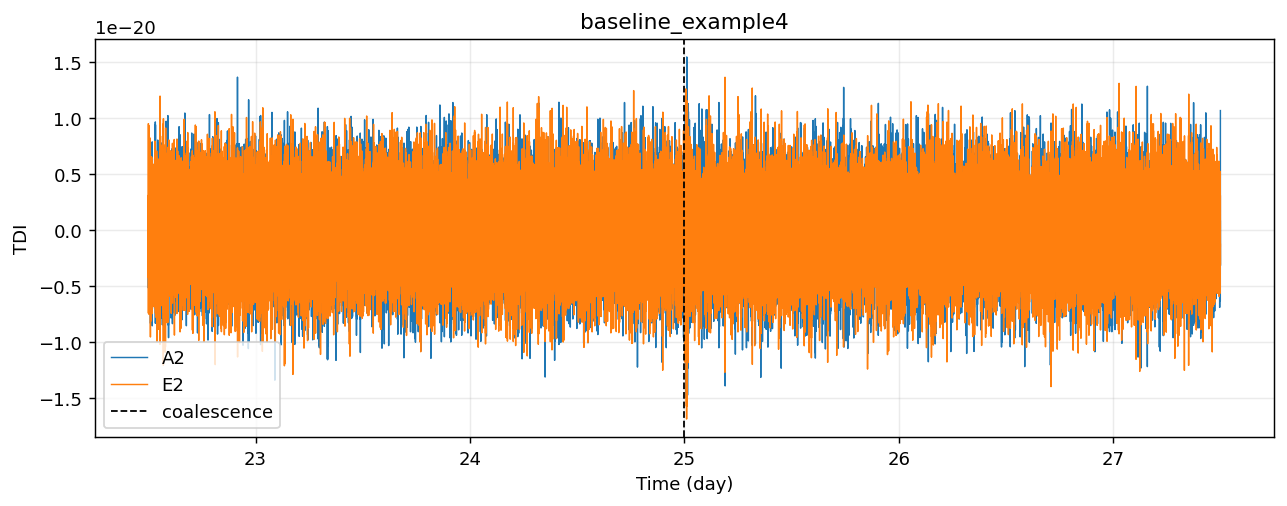

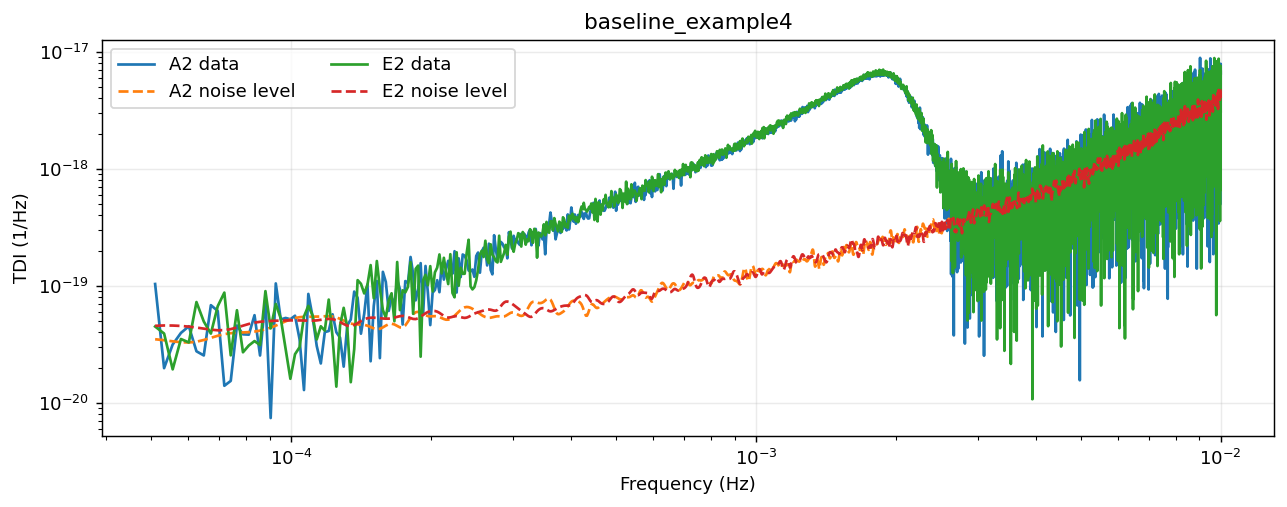

In [10]:
def plot_window_timeseries(window: dict, filename: str) -> None:
    plt.figure(figsize=(10, 4))
    for i, name in enumerate(channel_names):
        plt.plot(window["data_time"] / DAY, window["data_channels_td"][i], lw=0.8, label=name)
    plt.axvline(window["tc_day"], color="k", ls="--", lw=1.0, label="coalescence")
    plt.xlabel("Time (day)")
    plt.ylabel("TDI")
    plt.title(window["label"])
    plt.legend()
    save_current_figure(filename)

def plot_window_frequency(window: dict, filename: str) -> None:
    plt.figure(figsize=(10, 4))
    for i, name in enumerate(channel_names):
        plt.loglog(window["data_frequency"], np.abs(window["data_channels_fd"][i]), label=f"{name} data")
        plt.loglog(window["data_frequency"], np.sqrt(window["psd_channels"][i] * window["Tobs"] / 2.0), ls="--", label=f"{name} noise level")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("TDI (1/Hz)")
    plt.title(window["label"])
    plt.legend(ncol=2)
    save_current_figure(filename)

if baseline_window is not None:
    plot_window_timeseries(baseline_window, "01_baseline_timeseries.png")
    plot_window_frequency(baseline_window, "02_baseline_frequency_psd.png")
else:
    print("Baseline plots skipped.")


## 9. Model Setup Shared by Both Runs


In [11]:
orbit = None
WFG = None
FDTDI = None

if ORBIT_DIR.exists() and (baseline_window is not None or DATA_DIR.exists() or PARAM_DIR.exists()):
    orbit = Orbit(OrbitDir=str(ORBIT_DIR))
    WFG = WaveformGeneratorFRef(mode="primary")
    FDTDI = FDTDIResponseGeneratorFRef(orbit_class=orbit, waveform_generator=WFG)
    print("Orbit, WF4Py waveform generator, and FDTDI response generator initialized.")
else:
    print("Model setup skipped because orbit path or data files are unavailable.")

def build_response_kwargs(window: dict, interpolation_method="cubic") -> dict:
    return dict(fmin=FMIN, fmax=FMAX, fref=1e-3, modes=[(2, 2)], tmin=window["data_time"][0]/DAY, tmax=window["data_time"][-1]/DAY, tref_at_constellation=True, TDIGeneration="2nd", optimal_combination=True, drop_T=True, interpolation_method=interpolation_method)


Orbit, WF4Py waveform generator, and FDTDI response generator initialized.


## 10. F-statistics Search and Waveform Reconstruction

This migrates official Example 4 cells 18--30.


In [12]:
def build_intrinsic_priors(response_kwargs_direct: dict) -> np.ndarray:
    return np.array([[5.0, 7.0], [0.01, 0.99], [-0.9, 0.9], [-0.9, 0.9], [response_kwargs_direct["tmin"], response_kwargs_direct["tmax"]], [0.0, TWOPI], [-1.0, 1.0]])

def run_fstat_search(window: dict, maxiter: int | None = None, popsize_factor: int = 5) -> dict:
    if FDTDI is None:
        raise RuntimeError("Initialize FDTDI before running F-statistics search.")
    if maxiter is None:
        maxiter = SMOKE_TEST_SEARCH_MAXITER if USE_SMOKE_TEST_SEARCH else OFFICIAL_SEARCH_MAXITER
    response_kwargs_interp = build_response_kwargs(window, interpolation_method="cubic")
    response_kwargs_direct = response_kwargs_interp.copy()
    response_kwargs_direct["interpolation_method"] = None
    intrinsic_param_priors = build_intrinsic_priors(response_kwargs_direct)
    Fstat = FstatisticsFref(response_generator=FDTDI, frequency=window["data_frequency"], data=window["data_channels_fd"], invserse_covariance_matrix=window["InvCovMat"], response_parameters=response_kwargs_interp, use_gpu=False)

    def cost_function(norm_int_params):
        try:
            int_params = norm_int_params * (intrinsic_param_priors[:, 1] - intrinsic_param_priors[:, 0]) + intrinsic_param_priors[:, 0]
            return -Fstat.calculate_Fstat(intrinsic_parameters=Fstat.IntParamArr2ParamDict(int_params))
        except np.linalg.LinAlgError:
            return np.inf

    n_dim_int = 7
    bounds = np.array([np.zeros(n_dim_int), np.ones(n_dim_int)]).T
    DE_result = differential_evolution(func=cost_function, bounds=bounds, x0=None, strategy="best1exp", maxiter=maxiter, popsize=popsize_factor*n_dim_int, tol=1e-6, atol=1e-8, mutation=(0.4, 0.95), recombination=0.7, disp=True, polish=False, workers=DE_WORKERS)
    searched_int_params = Fstat.IntParamArr2ParamDict(DE_result.x * (intrinsic_param_priors[:, 1] - intrinsic_param_priors[:, 0]) + intrinsic_param_priors[:, 0])
    searched_a = Fstat.calculate_Fstat(intrinsic_parameters=searched_int_params, return_a=True)
    searched_parameters = dict(searched_int_params, **Fstat.a_to_extrinsic(searched_a))
    searched_wf = FDTDI.Response(searched_parameters, window["data_frequency"], **response_kwargs_interp)
    searched_parameters_reflected = get_reflected_parameter_dict_Fref(searched_params=searched_parameters, orbit=orbit)
    searched_wf_reflected = FDTDI.Response(parameters=searched_parameters_reflected, freqs=window["data_frequency"], **response_kwargs_interp)
    save_parameter_dict(searched_parameters, f"{window['label']}_searched_parameters.json")
    save_parameter_dict(searched_parameters_reflected, f"{window['label']}_searched_parameters_reflected.json")
    return dict(Fstat=Fstat, DE_result=DE_result, searched_parameters=searched_parameters, searched_parameters_reflected=searched_parameters_reflected, searched_wf=searched_wf, searched_wf_reflected=searched_wf_reflected, response_kwargs_interp=response_kwargs_interp, response_kwargs_direct=response_kwargs_direct, intrinsic_param_priors=intrinsic_param_priors)

def plot_reconstruction(window: dict, search: dict, reflected: bool, filename: str) -> None:
    wf_key = "searched_wf_reflected" if reflected else "searched_wf"
    title = "reflected" if reflected else "direct"
    plt.figure(figsize=(12, 5))
    for i, name in enumerate(channel_names):
        plt.subplot(1, 2, i+1)
        plt.loglog(window["data_frequency"], np.abs(window["data_channels_fd"][i]), label=f"{name} data", color=BLUE, lw=3, alpha=0.5)
        plt.loglog(window["data_frequency"], np.abs(search[wf_key][i]), label=f"{name} reconstructed", color=RED, lw=1, ls="--")
        plt.loglog(window["data_frequency"], np.abs(window["data_channels_fd"][i] - search[wf_key][i]), label=f"{name} residual", color="grey", lw=1)
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("TDI (1/Hz)")
        plt.ylim(1e-21, 1e-16)
        plt.legend(loc="upper left")
    plt.suptitle(f"{window['label']} reconstruction ({title})")
    save_current_figure(filename)

class CachedFisherErrors:
    def __init__(self, param_errors: dict[str, float]):
        self.param_errors = param_errors

def load_search_from_cache(window: dict) -> tuple[dict, CachedFisherErrors] | tuple[None, None]:
    param_path = RESULT_DIR / f"{window['label']}_searched_parameters.json"
    reflected_path = RESULT_DIR / f"{window['label']}_searched_parameters_reflected.json"
    fisher_path = RESULT_DIR / f"{window['label']}_fisher_errors.csv"
    if not (param_path.exists() and reflected_path.exists() and fisher_path.exists()):
        print(f"No cached search package found for {window['label']}.")
        return None, None
    if FDTDI is None:
        raise RuntimeError("Initialize FDTDI before loading cached search waveforms.")
    searched_parameters = json.loads(param_path.read_text(encoding="utf-8"))
    searched_parameters_reflected = json.loads(reflected_path.read_text(encoding="utf-8"))
    response_kwargs_interp = build_response_kwargs(window, interpolation_method="cubic")
    response_kwargs_direct = response_kwargs_interp.copy()
    response_kwargs_direct["interpolation_method"] = None
    searched_wf = FDTDI.Response(searched_parameters, window["data_frequency"], **response_kwargs_interp)
    searched_wf_reflected = FDTDI.Response(parameters=searched_parameters_reflected, freqs=window["data_frequency"], **response_kwargs_interp)
    fisher_errors = pd.read_csv(fisher_path).set_index("parameter")["fim_error"].to_dict()
    intrinsic_param_priors = build_intrinsic_priors(response_kwargs_direct)
    search = dict(Fstat=None, DE_result=None, searched_parameters=searched_parameters, searched_parameters_reflected=searched_parameters_reflected, searched_wf=searched_wf, searched_wf_reflected=searched_wf_reflected, response_kwargs_interp=response_kwargs_interp, response_kwargs_direct=response_kwargs_direct, intrinsic_param_priors=intrinsic_param_priors)
    print(f"Loaded cached search package for {window['label']} from {RESULT_DIR}.")
    return search, CachedFisherErrors(fisher_errors)


In [13]:
baseline_search = None
if RUN_CPU_EXAMPLE4_FSTAT:
    baseline_search = run_fstat_search(baseline_window)
    plot_reconstruction(baseline_window, baseline_search, reflected=False, filename="03_baseline_reconstruction_direct.png")
    plot_reconstruction(baseline_window, baseline_search, reflected=True, filename="04_baseline_reconstruction_reflected.png")
elif USE_CACHED_SEARCH_RESULTS:
    baseline_search, baseline_FIM = load_search_from_cache(baseline_window)
else:
    print("RUN_CPU_EXAMPLE4_FSTAT=False. CPU Example 4 F-statistics code is present but not executed.")


Loaded cached search package for baseline_example4 from /mnt/e/TDCEnv/Repos/task5-lisa-taiji/results/task5_subtask2.


## 11. Fisher Analysis

This migrates official Example 4 cells 31--36.


In [14]:
def run_fisher_analysis(window: dict, search: dict) -> MultiChannelFisher:
    def fisher_waveform_wrapper(param_dict, frequencies):
        return FDTDI.Response(parameters=param_dict, freqs=np.array(frequencies), **search["response_kwargs_interp"])
    analyze_param_step_dict = {"chirp_mass": -10.0, "mass_ratio": -0.01, "spin_1z": -0.01, "spin_2z": -0.01, "reference_time": -0.001, "reference_phase": -0.01, "luminosity_distance": -10.0, "inclination": -0.01, "longitude": -0.01, "latitude": -0.01, "psi": -0.01}
    FIM = MultiChannelFisher(waveform_generator=fisher_waveform_wrapper, param_dict=search["searched_parameters"], analyze_param_step_dict=analyze_param_step_dict, frequency=window["data_frequency"], inverse_covariance=window["InvCovMat"], verbose=0)
    FIM.auto_test_step()
    FIM.calculate_Fisher()
    FIM.calculate_errors()
    pd.DataFrame([{"parameter": k, "fim_error": v} for k, v in FIM.param_errors.items()]).to_csv(RESULT_DIR / f"{window['label']}_fisher_errors.csv", index=False)
    return FIM

def compare_search_to_injection(window: dict, search: dict, FIM) -> pd.DataFrame:
    injected_parameters_fref = injected_parameters.copy()
    injected_parameters_fref.pop("coalescence_time", None)
    injected_parameters_fref.pop("coalescence_phase", None)
    injected_parameters_fref["reference_time"] = None
    injected_parameters_fref["reference_phase"] = None
    rows = []
    for key, truth in injected_parameters_fref.items():
        if truth is None or key not in search["searched_parameters"]:
            continue
        reflected = search.get("searched_parameters_reflected", {})
        rows.append(dict(parameter=key, injected=truth, searched=search["searched_parameters"][key], searched_abs_error=abs(truth-search["searched_parameters"][key]), reflected=reflected.get(key), reflected_abs_error=abs(truth-reflected[key]) if key in reflected else np.nan, fim_error=FIM.param_errors.get(key, np.nan)))
    df = pd.DataFrame(rows)
    df.to_csv(RESULT_DIR / f"{window['label']}_search_vs_injection.csv", index=False)
    return df

baseline_FIM = globals().get("baseline_FIM")
baseline_search_comparison = None
if baseline_search is not None:
    if baseline_FIM is None:
        baseline_FIM = run_fisher_analysis(baseline_window, baseline_search)
    baseline_search_comparison = compare_search_to_injection(baseline_window, baseline_search, baseline_FIM)
    display(baseline_search_comparison)
else:
    print("Fisher analysis waiting for baseline_search.")


,parameter,injected,searched,searched_abs_error,reflected,reflected_abs_error,fim_error
0,chirp_mass,3.000000e+06,2.996266e+06,3734.294187,2.996266e+06,3734.294187,2468.835517
1,inclination,1.256637e+00,1.885013e+00,0.628376,1.256579e+00,0.000058,0.002571
2,latitude,5.235988e-01,-7.854060e-01,1.309005,2.180971e-01,0.305502,0.262226
3,longitude,4.712389e+00,2.203681e+00,2.508708,4.704024e+00,0.008365,0.286228
4,luminosity_distance,4.768947e+04,4.521189e+04,2477.587000,4.521189e+04,2477.587000,4065.331047
5,mass_ratio,2.500000e-01,2.505819e-01,0.000582,2.505819e-01,0.000582,0.001291
6,psi,9.424778e-01,1.840038e+00,0.897560,9.718415e-01,0.029364,0.185409
7,spin_1z,4.000000e-01,3.918637e-01,0.008136,3.918637e-01,0.008136,0.007922
8,spin_2z,6.000000e-01,6.284158e-01,0.028416,6.284158e-01,0.028416,0.036081


## 12. CPU Bilby/NESSAI Reference Path

This migrates official Example 4 cells 37--47 and is retained as a reference
fallback. It is not the default main route because the local CPU NESSAI run is
too slow for this task; the main route below uses official GPU BBHx + Eryn.


In [15]:
class BilbyLikelihoodWrapper(bilby.Likelihood):
    def __init__(self, like_object, like_type="heterodyned"):
        super().__init__(parameters={"chirp_mass": None, "mass_ratio": None, "spin_1z": None, "spin_2z": None, "reference_time": None, "reference_phase": None, "luminosity_distance": None, "inclination": None, "longitude": None, "latitude": None, "psi": None})
        self.like_object = like_object
        self.like_type = like_type
    def log_likelihood(self):
        parameter_array = ParamDict2ParamArrFref(self.parameters)
        if self.like_type == "heterodyned":
            return self.like_object.het_log_like(parameter_array=parameter_array)
        return self.like_object.full_log_like(parameter_array=parameter_array)

def build_likelihood(window: dict, search: dict) -> Likelihood:
    Like = Likelihood(response_generator=FDTDI, frequency=window["data_frequency"], data=window["data_channels_fd"], invserse_covariance_matrix=window["InvCovMat"], response_parameters=search["response_kwargs_direct"], Fref_waveform=True, use_gpu=False)
    Like.prepare_het_log_like(base_parameters=ParamDict2ParamArrFref(search["searched_parameters"]))
    return Like

def build_priors(search: dict, FIM) -> bilby.core.prior.PriorDict:
    sp, pe = search["searched_parameters"], FIM.param_errors
    priors = bilby.core.prior.PriorDict()
    nsig = FISHER_PRIOR_SIGMA
    priors["chirp_mass"] = bilby.prior.Uniform(sp["chirp_mass"]-nsig*pe["chirp_mass"], sp["chirp_mass"]+nsig*pe["chirp_mass"], name="chirp_mass", latex_label="$\\mathcal{M}_c$")
    priors["mass_ratio"] = bilby.prior.Uniform(max(0.1, sp["mass_ratio"]-nsig*pe["mass_ratio"]), min(0.99, sp["mass_ratio"]+nsig*pe["mass_ratio"]), name="mass_ratio", latex_label="$q$")
    priors["spin_1z"] = bilby.prior.Uniform(max(-0.9, sp["spin_1z"]-nsig*pe["spin_1z"]), min(0.9, sp["spin_1z"]+nsig*pe["spin_1z"]), name="spin_1z", latex_label="$\\chi_{z1}$")
    priors["spin_2z"] = bilby.prior.Uniform(max(-0.9, sp["spin_2z"]-nsig*pe["spin_2z"]), min(0.9, sp["spin_2z"]+nsig*pe["spin_2z"]), name="spin_2z", latex_label="$\\chi_{z2}$")
    priors["reference_time"] = bilby.prior.Uniform(sp["reference_time"]-nsig*pe["reference_time"], sp["reference_time"]+nsig*pe["reference_time"], name="reference_time", latex_label="$t_\\mathrm{ref}$")
    priors["reference_phase"] = bilby.prior.Uniform(0.0, TWOPI, name="reference_phase", latex_label="$\\varphi_\\mathrm{ref}$", boundary="periodic")
    priors["luminosity_distance"] = bilby.prior.Uniform(max(6e3, sp["luminosity_distance"]-nsig*pe["luminosity_distance"]), min(1e5, sp["luminosity_distance"]+nsig*pe["luminosity_distance"]), name="luminosity_distance", latex_label="$d_L$")
    priors["inclination"] = bilby.prior.Sine(minimum=0.0, maximum=PI, name="inclination", latex_label="$\\iota$")
    priors["longitude"] = bilby.prior.Uniform(0.0, TWOPI, name="longitude", latex_label="$\\lambda$", boundary="periodic")
    priors["latitude"] = bilby.prior.Cosine(minimum=-PI/2.0, maximum=PI/2.0, name="latitude", latex_label="$\\beta$")
    priors["psi"] = bilby.prior.Uniform(0.0, PI, name="psi", latex_label="$\\psi$", boundary="periodic")
    return priors

def build_injected_parameters_fref() -> dict:
    injected_parameters_fref = injected_parameters.copy()
    injected_parameters_fref.pop("coalescence_time", None)
    injected_parameters_fref.pop("coalescence_phase", None)
    injected_parameters_fref["reference_time"] = None
    injected_parameters_fref["reference_phase"] = None
    return injected_parameters_fref

PARAMETERS_TO_COMPARE = ["chirp_mass", "mass_ratio", "spin_1z", "spin_2z", "reference_time", "reference_phase", "luminosity_distance", "inclination", "longitude", "latitude", "psi"]

def run_nested_sampler(window: dict, search: dict, FIM, label: str, smoke_test: bool = True):
    if not smoke_test and "nessai" not in bilby.core.sampler.IMPLEMENTED_SAMPLERS:
        raise RuntimeError("This local bilby version does not support NESSAI. Use a Linux/conda environment with a newer bilby for the official sampler.")
    Like = build_likelihood(window, search)
    settings = SMOKE_TEST_SAMPLER_SETTINGS if smoke_test else OFFICIAL_SAMPLER_SETTINGS
    result = bilby.run_sampler(likelihood=BilbyLikelihoodWrapper(Like), priors=build_priors(search, FIM), npool=SAMPLER_POOL, injection_parameters=build_injected_parameters_fref(), outdir=str(RESULT_DIR / f"{label}_samples"), label=label, plot=False, resume=True, **settings)
    try:
        result.plot_corner(save=True)
    except Exception as exc:
        print(f"Corner plot skipped for {label}: {exc}")
    summary = posterior_summary(result.posterior, PARAMETERS_TO_COMPARE)
    summary.to_csv(RESULT_DIR / f"{label}_posterior_summary.csv", index=False)
    return result, summary

baseline_result = None
baseline_summary = None
if RUN_CPU_NESSAI:
    baseline_result, baseline_summary = run_nested_sampler(baseline_window, baseline_search, baseline_FIM, label="baseline_example4", smoke_test=USE_SMOKE_TEST_SAMPLER)
else:
    print("RUN_CPU_NESSAI=False. CPU Bilby/NESSAI sampler code is present but not executed.")


RUN_CPU_NESSAI=False. CPU Bilby/NESSAI sampler code is present but not executed.


## 13. Build Task-Required 5-Day Window


[task_five_day]
mode: task_five_day
tc_day: 25.0
start_day/end_day: 21.0 26.0
duration_days: 5.0
dt: 10.0
Tobs: 432010.0
df median: 2.3147612323790034e-06
expected 1/Tobs: 2.31476123237888e-06
data_td: (2, 43201)
data_fd: (2, 4299)
InvCovMat: (4299, 2, 2)
PSD mode/samples: before 181440


Saved: figures/task5_subtask2/05_five_day_timeseries.png


Saved: figures/task5_subtask2/06_five_day_frequency_psd.png


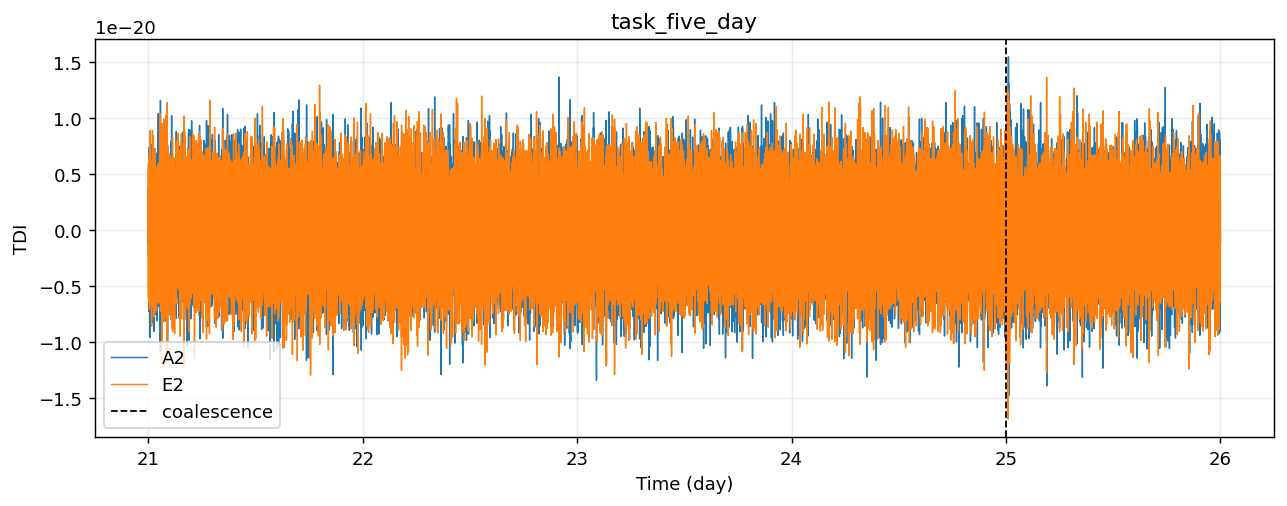

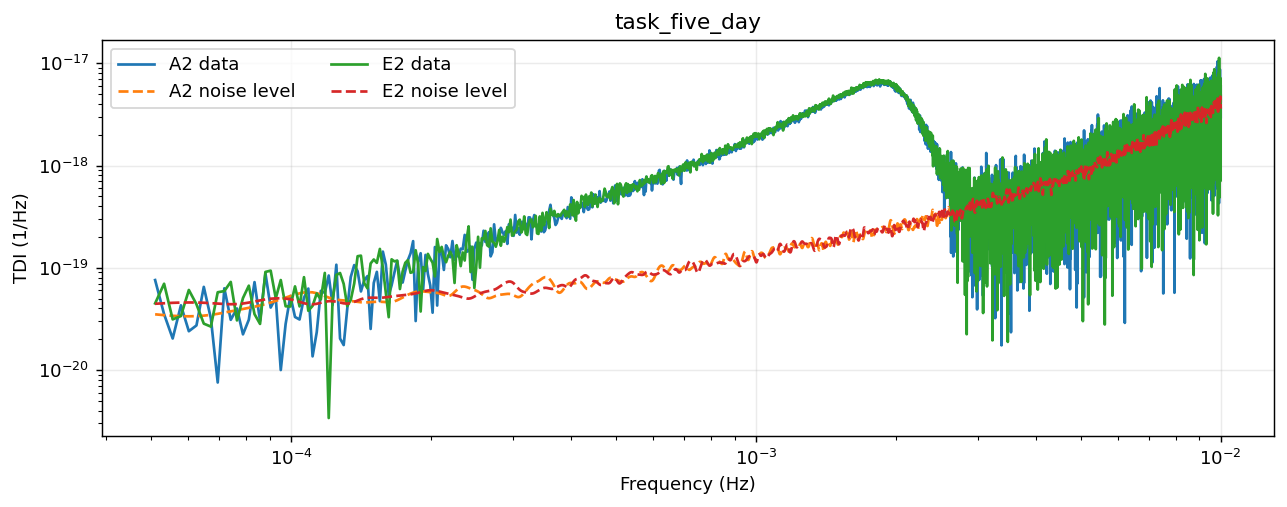

In [16]:
five_day_window = None
if read_dict is not None:
    five_day_window = build_window_data("task_five_day", "task_five_day", psd_mode="before")
    print_window_summary(five_day_window)
    plot_window_timeseries(five_day_window, "05_five_day_timeseries.png")
    plot_window_frequency(five_day_window, "06_five_day_frequency_psd.png")
else:
    print("Skipping 5-day window because data is not loaded.")


## 14. Run Search, Fisher, Likelihood, and Sampler on the 5-Day Window


In [17]:
five_day_search = None
five_day_FIM = None
five_day_search_comparison = None
if RUN_CPU_EXAMPLE4_FSTAT:
    five_day_search = run_fstat_search(five_day_window)
    plot_reconstruction(five_day_window, five_day_search, reflected=False, filename="07_five_day_reconstruction_direct.png")
    plot_reconstruction(five_day_window, five_day_search, reflected=True, filename="08_five_day_reconstruction_reflected.png")
    five_day_FIM = run_fisher_analysis(five_day_window, five_day_search)
    five_day_search_comparison = compare_search_to_injection(five_day_window, five_day_search, five_day_FIM)
    display(five_day_search_comparison)
elif USE_CACHED_SEARCH_RESULTS:
    five_day_search, five_day_FIM = load_search_from_cache(five_day_window)
    if five_day_search is not None:
        five_day_search_comparison = compare_search_to_injection(five_day_window, five_day_search, five_day_FIM)
        display(five_day_search_comparison)
else:
    print("RUN_CPU_EXAMPLE4_FSTAT=False. Modified-window CPU search code is present but not executed.")

five_day_result = None
five_day_summary = None
if RUN_CPU_NESSAI:
    five_day_result, five_day_summary = run_nested_sampler(five_day_window, five_day_search, five_day_FIM, label="task_five_day", smoke_test=USE_SMOKE_TEST_SAMPLER)
else:
    print("RUN_CPU_NESSAI=False. Modified-window CPU sampler code is present but not executed.")


Loaded cached search package for task_five_day from /mnt/e/TDCEnv/Repos/task5-lisa-taiji/results/task5_subtask2.


,parameter,injected,searched,searched_abs_error,reflected,reflected_abs_error,fim_error
0,chirp_mass,3.000000e+06,2.988490e+06,11509.851758,2.988490e+06,11509.851758,2125.604981
1,inclination,1.256637e+00,1.882945e+00,0.626308,1.258647e+00,0.002010,0.011928
2,latitude,5.235988e-01,9.959564e-02,0.424003,1.125718e+00,0.602119,0.206405
3,longitude,4.712389e+00,1.687008e+00,3.025381,5.307218e+00,0.594829,0.172382
4,luminosity_distance,4.768947e+04,3.906251e+04,8626.966055,3.906251e+04,8626.966055,6224.242637
5,mass_ratio,2.500000e-01,2.462632e-01,0.003737,2.462632e-01,0.003737,0.001197
6,psi,9.424778e-01,2.095197e+00,1.152719,1.337087e+00,0.394609,0.027849
7,spin_1z,4.000000e-01,4.062726e-01,0.006273,4.062726e-01,0.006273,0.007547
8,spin_2z,6.000000e-01,5.658009e-01,0.034199,5.658009e-01,0.034199,0.034998


RUN_CPU_NESSAI=False. Modified-window CPU sampler code is present but not executed.


## 15. Baseline vs Modified-Window Comparison


In [18]:
def compare_summaries(baseline_summary: pd.DataFrame, five_day_summary: pd.DataFrame) -> pd.DataFrame:
    base = baseline_summary.add_prefix("baseline_").rename(columns={"baseline_parameter": "parameter"})
    five = five_day_summary.add_prefix("five_day_").rename(columns={"five_day_parameter": "parameter"})
    merged = pd.merge(base, five, on="parameter", how="outer")
    expected = set(PARAMETERS_TO_COMPARE) | {"coalescence_time", "coalescence_phase"}
    missing = sorted(expected - set(merged["parameter"].dropna()))
    if missing:
        print("Warning: comparison table is missing parameters:", missing)
    merged["ci90_width_ratio_5day_over_baseline"] = merged["five_day_ci90_width"] / merged["baseline_ci90_width"]
    return merged

comparison = pd.DataFrame(columns=["parameter", "baseline_median", "baseline_ci90_low", "baseline_ci90_high", "baseline_ci90_width", "five_day_median", "five_day_ci90_low", "five_day_ci90_high", "five_day_ci90_width", "ci90_width_ratio_5day_over_baseline"])
if baseline_summary is not None and five_day_summary is not None:
    comparison = compare_summaries(baseline_summary, five_day_summary)
    comparison.to_csv(RESULT_DIR / "baseline_vs_five_day_parameter_summary.csv", index=False)
display(comparison)


,parameter,baseline_median,baseline_ci90_low,baseline_ci90_high,baseline_ci90_width,five_day_median,five_day_ci90_low,five_day_ci90_high,five_day_ci90_width,ci90_width_ratio_5day_over_baseline


## 16. Taiji-Frame Sky Position Plot


In [19]:
def plot_taiji_frame_position(result, label: str, filename: str) -> None:
    num_sample = len(result.posterior["longitude"])
    longitude_TJ = np.zeros(num_sample)
    latitude_TJ = np.zeros(num_sample)
    for i in range(num_sample):
        lon, lat, _ = SSBPosToDetectorFrame(lon_ssb=result.posterior["longitude"][i], lat_ssb=result.posterior["latitude"][i], psi_ssb=result.posterior["psi"][i], orbit_time_SI=injected_parameters["coalescence_time"]*DAY, orbit=orbit)
        longitude_TJ[i] = lon % TWOPI
        latitude_TJ[i] = lat
    plt.figure(figsize=(5.2, 4.4))
    plt.hist2d(x=longitude_TJ, y=latitude_TJ, bins=50)
    plt.xlabel("longitude (rad)")
    plt.ylabel("latitude (rad)")
    plt.title(label)
    save_current_figure(filename)

if baseline_result is not None:
    plot_taiji_frame_position(baseline_result, "baseline Taiji-frame sky position", "09_baseline_taiji_frame_sky.png")
if five_day_result is not None:
    plot_taiji_frame_position(five_day_result, "five-day Taiji-frame sky position", "10_five_day_taiji_frame_sky.png")
if baseline_result is None and five_day_result is None:
    print("Sky-position plots waiting for sampler results.")


Sky-position plots waiting for sampler results.


## 17. Result Manifest for README


In [20]:
manifest = {
    "baseline_timeseries": "figures/task5_subtask2/01_baseline_timeseries.png",
    "baseline_frequency_psd": "figures/task5_subtask2/02_baseline_frequency_psd.png",
    "baseline_reconstruction_direct": "figures/task5_subtask2/03_baseline_reconstruction_direct.png",
    "baseline_reconstruction_reflected": "figures/task5_subtask2/04_baseline_reconstruction_reflected.png",
    "five_day_timeseries": "figures/task5_subtask2/05_five_day_timeseries.png",
    "five_day_frequency_psd": "figures/task5_subtask2/06_five_day_frequency_psd.png",
    "five_day_reconstruction_direct": "figures/task5_subtask2/07_five_day_reconstruction_direct.png",
    "five_day_reconstruction_reflected": "figures/task5_subtask2/08_five_day_reconstruction_reflected.png",
    "baseline_taiji_frame_sky": "figures/task5_subtask2/09_baseline_taiji_frame_sky.png",
    "five_day_taiji_frame_sky": "figures/task5_subtask2/10_five_day_taiji_frame_sky.png",
    "comparison_table": "results/task5_subtask2/baseline_vs_five_day_parameter_summary.csv",
    "baseline_gpu_preflight": "results/task5_subtask2/baseline_example4_gpu_preflight.json",
    "baseline_gpu_search": "results/task5_subtask2/baseline_example4_gpu_searched_parameters.json",
    "baseline_gpu_reflected_search": "results/task5_subtask2/baseline_example4_gpu_searched_parameters_reflected.json",
    "baseline_gpu_nessai_posterior": "results/task5_subtask2/baseline_example4_gpu_nessai_posterior_summary.csv",
    "baseline_gpu_nessai_evidence": "results/task5_subtask2/baseline_example4_gpu_nessai_evidence.json",
    "baseline_gpu_nessai_diagnostics": "results/task5_subtask2/baseline_example4_gpu_nessai_diagnostics.json",
    "baseline_gpu_nessai_native_diagnostics": "results/task5_subtask2/baseline_example4_gpu_nessai_native_diagnostics.json",
    "baseline_gpu_nessai_boundary_check": "results/task5_subtask2/baseline_example4_gpu_nessai_boundary_check.csv",
    "baseline_gpu_eryn_posterior": "results/task5_subtask2/baseline_example4_gpu_eryn_posterior_summary.csv",
    "five_day_gpu_preflight": "results/task5_subtask2/task_five_day_gpu_preflight.json",
    "five_day_gpu_search": "results/task5_subtask2/task_five_day_gpu_searched_parameters.json",
    "five_day_gpu_reflected_search": "results/task5_subtask2/task_five_day_gpu_searched_parameters_reflected.json",
    "five_day_gpu_nessai_posterior": "results/task5_subtask2/task_five_day_gpu_nessai_posterior_summary.csv",
    "five_day_gpu_nessai_evidence": "results/task5_subtask2/task_five_day_gpu_nessai_evidence.json",
    "five_day_gpu_nessai_diagnostics": "results/task5_subtask2/task_five_day_gpu_nessai_diagnostics.json",
    "five_day_gpu_nessai_native_diagnostics": "results/task5_subtask2/task_five_day_gpu_nessai_native_diagnostics.json",
    "five_day_gpu_nessai_boundary_check": "results/task5_subtask2/task_five_day_gpu_nessai_boundary_check.csv",
    "five_day_gpu_eryn_posterior": "results/task5_subtask2/task_five_day_gpu_eryn_posterior_summary.csv",
    "gpu_comparison_table": "results/task5_subtask2/baseline_vs_five_day_gpu_nessai_parameter_summary.csv",
}
save_json(manifest, "manifest.json")
print(json.dumps(manifest, indent=2, ensure_ascii=False))


Saved: results/task5_subtask2/manifest.json
{
  "baseline_timeseries": "figures/task5_subtask2/01_baseline_timeseries.png",
  "baseline_frequency_psd": "figures/task5_subtask2/02_baseline_frequency_psd.png",
  "baseline_reconstruction_direct": "figures/task5_subtask2/03_baseline_reconstruction_direct.png",
  "baseline_reconstruction_reflected": "figures/task5_subtask2/04_baseline_reconstruction_reflected.png",
  "five_day_timeseries": "figures/task5_subtask2/05_five_day_timeseries.png",
  "five_day_frequency_psd": "figures/task5_subtask2/06_five_day_frequency_psd.png",
  "five_day_reconstruction_direct": "figures/task5_subtask2/07_five_day_reconstruction_direct.png",
  "five_day_reconstruction_reflected": "figures/task5_subtask2/08_five_day_reconstruction_reflected.png",
  "baseline_taiji_frame_sky": "figures/task5_subtask2/09_baseline_taiji_frame_sky.png",
  "five_day_taiji_frame_sky": "figures/task5_subtask2/10_five_day_taiji_frame_sky.png",
  "comparison_table": "results/task5_subta

## 18. Official GPU Route: BBHx, GPU F-statistics, and NESSAI

The official Triangle-BBH GPU notebooks use `BBHxWaveformGenerator` and
`BBHxFDTDIResponseGenerator` with `use_gpu=True`. This notebook keeps the task's
NESSAI requirement by wrapping the GPU heterodyned likelihood in a vectorised
`nessai.model.Model`. The Eryn route is retained only as a fallback and
pipeline cross-check.


In [21]:
WFG_GPU = None
FDTDI_GPU = None

def initialize_gpu_model():
    global WFG_GPU, FDTDI_GPU
    if not USE_GPU_BBHX:
        print("USE_GPU_BBHX=False; GPU route disabled.")
        return None, None
    if not HAS_CUPY:
        raise RuntimeError("CuPy is not available in this kernel.")
    if orbit is None:
        raise RuntimeError("Initialize Orbit before the GPU model.")
    WFG_GPU = BBHxWaveformGenerator(mode="primary", use_gpu=True)
    FDTDI_GPU = BBHxFDTDIResponseGenerator(orbit_class=orbit, waveform_generator=WFG_GPU, use_gpu=True)
    print("Initialized official BBHx GPU waveform and TDI response generators.")
    return WFG_GPU, FDTDI_GPU

if USE_GPU_BBHX and baseline_window is not None:
    initialize_gpu_model()


Initialized official BBHx GPU waveform and TDI response generators.


In [22]:
def to_gpu_window(window: dict) -> dict:
    return dict(
        frequency=xp.asarray(window["data_frequency"]),
        data=xp.asarray(window["data_channels_fd"]),
        inv_covariance=xp.asarray(window["InvCovMat"]),
    )

def build_gpu_response_kwargs(window: dict, interpolation: bool = True) -> dict:
    return dict(
        modes=[(2, 2)],
        tmin=window["data_time"][0] / DAY,
        tmax=window["data_time"][-1] / DAY,
        tc_at_constellation=True,
        TDIGeneration="2nd",
        optimal_combination=True,
        drop_T=True,
        interpolation=interpolation,
    )

def run_gpu_preflight(window: dict, label: str = "baseline_example4") -> dict:
    if FDTDI_GPU is None:
        raise RuntimeError("Initialize FDTDI_GPU before GPU preflight.")
    gpu_window = to_gpu_window(window)
    response_kwargs_interp = build_gpu_response_kwargs(window, interpolation=True)
    response_kwargs_direct = build_gpu_response_kwargs(window, interpolation=False)
    wf = FDTDI_GPU.Response(
        parameters=injected_parameters,
        freqs=gpu_window["frequency"],
        **response_kwargs_interp,
    )
    residual = gpu_window["data"] - wf
    residual_norm = float(xp.linalg.norm(residual).get())
    data_norm = float(xp.linalg.norm(gpu_window["data"]).get())
    Like_preflight = Likelihood(
        response_generator=FDTDI_GPU,
        frequency=gpu_window["frequency"],
        data=gpu_window["data"],
        invserse_covariance_matrix=gpu_window["inv_covariance"],
        response_parameters=response_kwargs_direct,
        use_gpu=True,
    )
    injected_array = ParamDict2ParamArr(injected_parameters)
    Like_preflight.prepare_het_log_like(base_parameters=injected_array)
    log_likelihood_at_injection = float(Like_preflight.het_log_like(parameter_array=injected_array))
    report = {
        "label": label,
        "gpu_device_count": int(xp.cuda.runtime.getDeviceCount()),
        "frequency_bins": int(gpu_window["frequency"].shape[0]),
        "channels": int(gpu_window["data"].shape[0]),
        "waveform_shape": tuple(int(i) for i in wf.shape),
        "data_norm": data_norm,
        "injection_waveform_norm": float(xp.linalg.norm(wf).get()),
        "residual_norm": residual_norm,
        "residual_over_data": residual_norm / data_norm if data_norm else np.nan,
        "log_likelihood_at_injection": log_likelihood_at_injection,
        "heterodyned_log_likelihood_at_injection": log_likelihood_at_injection,
    }
    save_json(report, f"{label}_gpu_preflight.json")
    print(json.dumps(report, indent=2, ensure_ascii=False))
    return dict(gpu_window=gpu_window, response_kwargs_interp=response_kwargs_interp, response_kwargs_direct=response_kwargs_direct, injected_wf=wf, report=report)

baseline_gpu_preflight = None
if RUN_GPU_PREFLIGHT and baseline_window is not None and FDTDI_GPU is not None:
    baseline_gpu_preflight = run_gpu_preflight(baseline_window, "baseline_example4")
else:
    print("GPU preflight skipped.")


Saved: results/task5_subtask2/baseline_example4_gpu_preflight.json
{
  "label": "baseline_example4",
  "gpu_device_count": 1,
  "frequency_bins": 4299,
  "channels": 2,
  "waveform_shape": [
    2,
    4299
  ],
  "data_norm": 2.2752314376525393e-16,
  "injection_waveform_norm": 1.5877225614832737e-16,
  "residual_norm": 2.522935246824987e-16,
  "residual_over_data": 1.108869719832992,
  "log_likelihood_at_injection": -383859.58977194433,
  "heterodyned_log_likelihood_at_injection": -383859.58977194433
}


Loaded cached GPU search package for baseline_example4 from /mnt/e/TDCEnv/Repos/task5-lisa-taiji/results/task5_subtask2.


Saved: figures/task5_subtask2/03_baseline_reconstruction_direct.png


Saved: figures/task5_subtask2/04_baseline_reconstruction_reflected.png


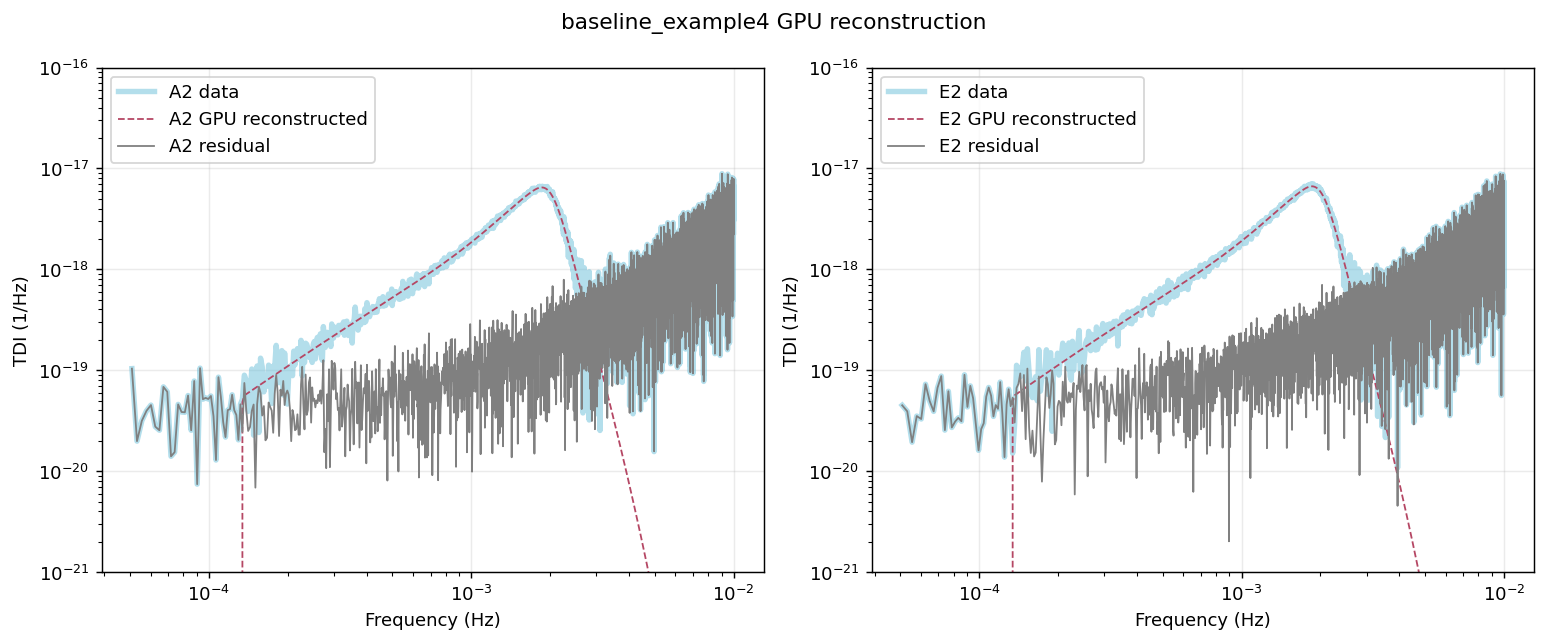

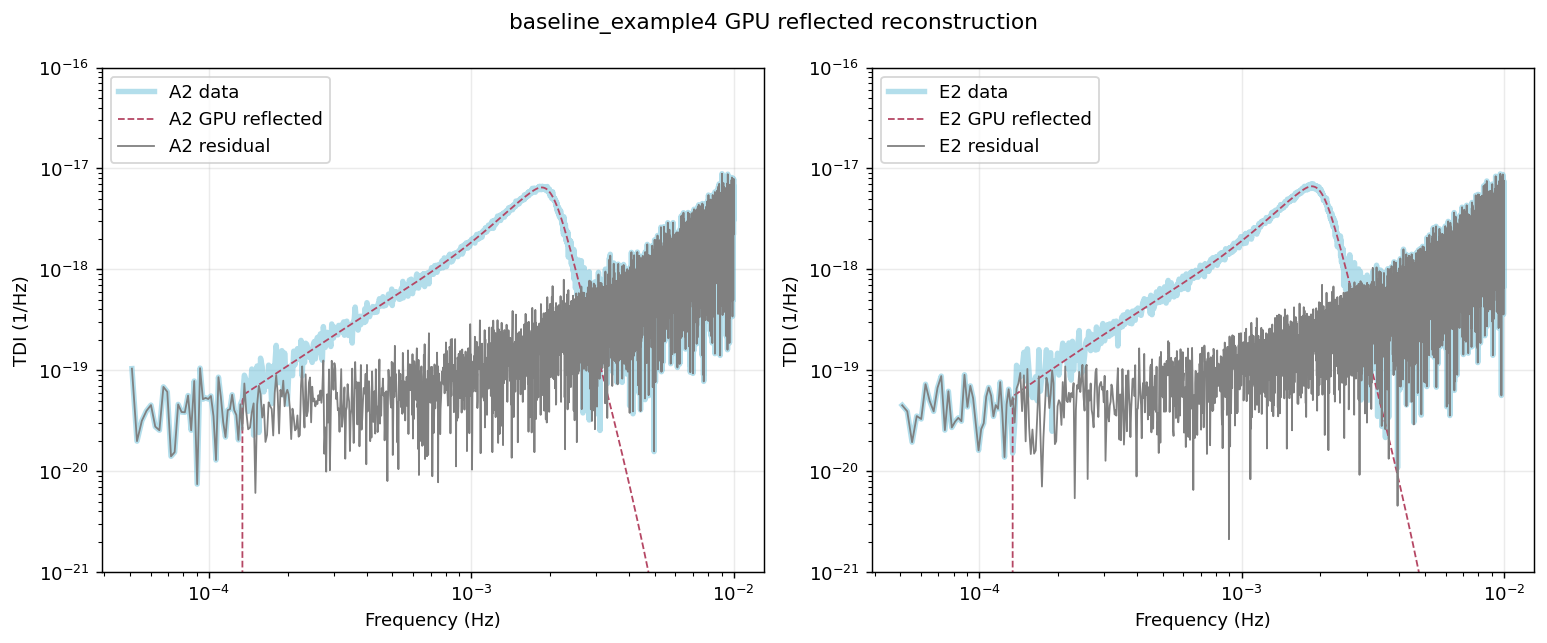

In [23]:
def build_gpu_intrinsic_priors(response_kwargs_direct: dict) -> np.ndarray:
    return np.array([
        [5.0, 7.0],
        [0.01, 0.99],
        [-0.9, 0.9],
        [-0.9, 0.9],
        [response_kwargs_direct["tmin"], response_kwargs_direct["tmax"]],
        [0.0, TWOPI],
        [-1.0, 1.0],
    ])

def run_gpu_fstat_search(window: dict, label: str, maxiter: int = GPU_SEARCH_MAXITER) -> dict:
    if FDTDI_GPU is None:
        raise RuntimeError("Initialize FDTDI_GPU before the GPU F-statistics search.")
    gpu_window = to_gpu_window(window)
    response_kwargs_interp = build_gpu_response_kwargs(window, interpolation=True)
    response_kwargs_direct = build_gpu_response_kwargs(window, interpolation=False)
    intrinsic_param_priors = build_gpu_intrinsic_priors(response_kwargs_direct)
    Fstat_gpu = Fstatistics(
        response_generator=FDTDI_GPU,
        frequency=gpu_window["frequency"],
        data=gpu_window["data"],
        invserse_covariance_matrix=gpu_window["inv_covariance"],
        response_parameters=response_kwargs_interp,
        use_gpu=True,
    )

    def cost_function(norm_int_params):
        try:
            int_params = norm_int_params.transpose() * (intrinsic_param_priors[:, 1] - intrinsic_param_priors[:, 0]) + intrinsic_param_priors[:, 0]
            params_in = Fstat_gpu.IntParamArr2ParamDict(int_params.transpose())
            return -Fstat_gpu.calculate_Fstat_vectorized(intrinsic_parameters=params_in)
        except xp.linalg.LinAlgError:
            return np.inf * np.ones(norm_int_params.shape[1])

    n_dim_int = 7
    bounds = np.array([np.zeros(n_dim_int), np.ones(n_dim_int)]).T
    DE_result = differential_evolution(
        func=cost_function,
        bounds=bounds,
        x0=None,
        strategy="best1exp",
        maxiter=maxiter,
        popsize=5 * n_dim_int,
        tol=1e-6,
        atol=1e-8,
        mutation=(0.4, 0.95),
        recombination=0.7,
        disp=True,
        vectorized=True,
        polish=False,
    )
    searched_int_params = Fstat_gpu.IntParamArr2ParamDict(DE_result.x * (intrinsic_param_priors[:, 1] - intrinsic_param_priors[:, 0]) + intrinsic_param_priors[:, 0])
    searched_a = Fstat_gpu.calculate_Fstat(intrinsic_parameters=searched_int_params, return_a=True)
    searched_ext_params = Fstat_gpu.a_to_extrinsic(searched_a)
    searched_parameters = dict(searched_int_params, **searched_ext_params)
    searched_parameters = {k: float(v) for k, v in searched_parameters.items()}
    searched_wf = FDTDI_GPU.Response(searched_parameters, gpu_window["frequency"], **response_kwargs_interp)
    searched_parameters_reflected = get_reflected_parameter_dict(searched_params=searched_parameters, orbit=orbit)
    searched_parameters_reflected = {k: float(v) for k, v in searched_parameters_reflected.items()}
    searched_wf_reflected = FDTDI_GPU.Response(searched_parameters_reflected, gpu_window["frequency"], **response_kwargs_interp)
    save_parameter_dict(searched_parameters, f"{label}_gpu_searched_parameters.json")
    save_parameter_dict(searched_parameters_reflected, f"{label}_gpu_searched_parameters_reflected.json")
    search_report = {
        "label": label,
        "success": bool(DE_result.success),
        "message": str(DE_result.message),
        "fun": float(DE_result.fun),
        "nit": int(DE_result.nit),
        "nfev": int(DE_result.nfev),
    }
    save_json(search_report, f"{label}_gpu_search_report.json")
    return dict(
        Fstat=Fstat_gpu,
        DE_result=DE_result,
        searched_parameters=searched_parameters,
        searched_parameters_reflected=searched_parameters_reflected,
        searched_wf=searched_wf,
        searched_wf_reflected=searched_wf_reflected,
        gpu_window=gpu_window,
        response_kwargs_interp=response_kwargs_interp,
        response_kwargs_direct=response_kwargs_direct,
        intrinsic_param_priors=intrinsic_param_priors,
    )

def load_gpu_search_from_cache(window: dict, label: str) -> tuple[dict, CachedFisherErrors] | tuple[None, None]:
    param_path = RESULT_DIR / f"{label}_gpu_searched_parameters.json"
    reflected_path = RESULT_DIR / f"{label}_gpu_searched_parameters_reflected.json"
    fisher_path = RESULT_DIR / f"{label}_gpu_fisher_errors.csv"
    if not (param_path.exists() and reflected_path.exists() and fisher_path.exists()):
        print(f"No cached GPU search package found for {label}.")
        return None, None
    if FDTDI_GPU is None:
        raise RuntimeError("Initialize FDTDI_GPU before loading cached GPU search waveforms.")
    gpu_window = to_gpu_window(window)
    response_kwargs_interp = build_gpu_response_kwargs(window, interpolation=True)
    response_kwargs_direct = build_gpu_response_kwargs(window, interpolation=False)
    searched_parameters = json.loads(param_path.read_text(encoding="utf-8"))
    searched_parameters_reflected = json.loads(reflected_path.read_text(encoding="utf-8"))
    searched_wf = FDTDI_GPU.Response(searched_parameters, gpu_window["frequency"], **response_kwargs_interp)
    searched_wf_reflected = FDTDI_GPU.Response(searched_parameters_reflected, gpu_window["frequency"], **response_kwargs_interp)
    fisher_errors = pd.read_csv(fisher_path).set_index("parameter")["fim_error"].to_dict()
    intrinsic_param_priors = build_gpu_intrinsic_priors(response_kwargs_direct)
    search = dict(
        Fstat=None,
        DE_result=None,
        searched_parameters={k: float(v) for k, v in searched_parameters.items()},
        searched_parameters_reflected={k: float(v) for k, v in searched_parameters_reflected.items()},
        searched_wf=searched_wf,
        searched_wf_reflected=searched_wf_reflected,
        gpu_window=gpu_window,
        response_kwargs_interp=response_kwargs_interp,
        response_kwargs_direct=response_kwargs_direct,
        intrinsic_param_priors=intrinsic_param_priors,
    )
    print(f"Loaded cached GPU search package for {label} from {RESULT_DIR}.")
    return search, CachedFisherErrors(fisher_errors)

def plot_gpu_reconstruction(window: dict, gpu_search: dict, filename: str) -> None:
    searched_wf = gpu_search["searched_wf"].get()
    plt.figure(figsize=(12, 5))
    for i, name in enumerate(channel_names):
        plt.subplot(1, 2, i+1)
        plt.loglog(window["data_frequency"], np.abs(window["data_channels_fd"][i]), label=f"{name} data", color=BLUE, lw=3, alpha=0.5)
        plt.loglog(window["data_frequency"], np.abs(searched_wf[i]), label=f"{name} GPU reconstructed", color=RED, lw=1, ls="--")
        plt.loglog(window["data_frequency"], np.abs(window["data_channels_fd"][i] - searched_wf[i]), label=f"{name} residual", color="grey", lw=1)
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("TDI (1/Hz)")
        plt.ylim(1e-21, 1e-16)
        plt.legend(loc="upper left")
    plt.suptitle(f"{window['label']} GPU reconstruction")
    save_current_figure(filename)

def plot_gpu_reflected_reconstruction(window: dict, gpu_search: dict, filename: str) -> None:
    if "searched_wf_reflected" not in gpu_search:
        print(f"No reflected GPU waveform available for {window['label']}.")
        return
    searched_wf = gpu_search["searched_wf_reflected"].get()
    plt.figure(figsize=(12, 5))
    for i, name in enumerate(channel_names):
        plt.subplot(1, 2, i+1)
        plt.loglog(window["data_frequency"], np.abs(window["data_channels_fd"][i]), label=f"{name} data", color=BLUE, lw=3, alpha=0.5)
        plt.loglog(window["data_frequency"], np.abs(searched_wf[i]), label=f"{name} GPU reflected", color=RED, lw=1, ls="--")
        plt.loglog(window["data_frequency"], np.abs(window["data_channels_fd"][i] - searched_wf[i]), label=f"{name} residual", color="grey", lw=1)
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("TDI (1/Hz)")
        plt.ylim(1e-21, 1e-16)
        plt.legend(loc="upper left")
    plt.suptitle(f"{window['label']} GPU reflected reconstruction")
    save_current_figure(filename)

baseline_gpu_search = None
baseline_gpu_FIM = None
if USE_CACHED_SEARCH_RESULTS and baseline_window is not None:
    baseline_gpu_search, baseline_gpu_FIM = load_gpu_search_from_cache(baseline_window, "baseline_example4")
    if baseline_gpu_search is not None:
        plot_gpu_reconstruction(baseline_window, baseline_gpu_search, "03_baseline_reconstruction_direct.png")
        plot_gpu_reflected_reconstruction(baseline_window, baseline_gpu_search, "04_baseline_reconstruction_reflected.png")
elif RUN_GPU_FSTAT_SEARCH and baseline_window is not None:
    baseline_gpu_search = run_gpu_fstat_search(baseline_window, "baseline_example4")
    plot_gpu_reconstruction(baseline_window, baseline_gpu_search, "03_baseline_reconstruction_direct.png")
    plot_gpu_reflected_reconstruction(baseline_window, baseline_gpu_search, "04_baseline_reconstruction_reflected.png")
else:
    print("GPU F-statistics search code is present but not executed.")


In [24]:
def run_gpu_fisher_analysis(window: dict, gpu_search: dict) -> MultiChannelFisher:
    def fisher_waveform_wrapper(param_dict, frequencies):
        res = FDTDI_GPU.Response(
            parameters=param_dict,
            freqs=xp.asarray(frequencies),
            **gpu_search["response_kwargs_interp"],
        )
        return res.get()

    analyze_param_step_dict = {
        "chirp_mass": -10.0,
        "mass_ratio": -0.01,
        "spin_1z": -0.01,
        "spin_2z": -0.01,
        "coalescence_time": -0.001,
        "coalescence_phase": -0.01,
        "luminosity_distance": -10.0,
        "inclination": -0.01,
        "longitude": -0.01,
        "latitude": -0.01,
        "psi": -0.01,
    }
    FIM_gpu = MultiChannelFisher(
        waveform_generator=fisher_waveform_wrapper,
        param_dict=gpu_search["searched_parameters"],
        analyze_param_step_dict=analyze_param_step_dict,
        frequency=gpu_search["gpu_window"]["frequency"].get(),
        inverse_covariance=gpu_search["gpu_window"]["inv_covariance"].get(),
        verbose=0,
    )
    FIM_gpu.auto_test_step()
    FIM_gpu.calculate_Fisher()
    FIM_gpu.calculate_errors()
    pd.DataFrame([{"parameter": k, "fim_error": v} for k, v in FIM_gpu.param_errors.items()]).to_csv(RESULT_DIR / f"{window['label']}_gpu_fisher_errors.csv", index=False)
    return FIM_gpu

if "baseline_gpu_FIM" not in globals():
    baseline_gpu_FIM = None
if RUN_GPU_FISHER and baseline_gpu_search is not None and baseline_gpu_FIM is None:
    baseline_gpu_FIM = run_gpu_fisher_analysis(baseline_window, baseline_gpu_search)
if baseline_gpu_search is not None and baseline_gpu_FIM is not None:
    baseline_gpu_search_comparison = compare_search_to_injection(baseline_window, baseline_gpu_search, baseline_gpu_FIM)
    baseline_gpu_search_comparison.to_csv(RESULT_DIR / "baseline_example4_gpu_search_vs_injection.csv", index=False)
    display(baseline_gpu_search_comparison)
else:
    print("GPU Fisher code is present but not executed.")


,parameter,injected,searched,searched_abs_error,reflected,reflected_abs_error,fim_error
0,chirp_mass,3.000000e+06,2.996932e+06,3068.393954,2.996932e+06,3068.393954,2462.629081
1,inclination,1.256637e+00,1.885193e+00,0.628556,1.256399e+00,0.000238,0.002734
2,latitude,5.235988e-01,-7.850421e-01,1.308641,2.257223e-01,0.297877,0.263604
3,longitude,4.712389e+00,2.170739e+00,2.541650,4.727004e+00,0.014615,0.292569
4,luminosity_distance,4.768947e+04,4.554646e+04,2143.010851,4.554646e+04,2143.010851,4033.666575
5,mass_ratio,2.500000e-01,2.504410e-01,0.000441,2.504410e-01,0.000441,0.001272
6,psi,9.424778e-01,1.860925e+00,0.918448,9.794155e-01,0.036938,0.187746
7,spin_1z,4.000000e-01,3.946286e-01,0.005371,3.946286e-01,0.005371,0.007849
8,spin_2z,6.000000e-01,6.167841e-01,0.016784,6.167841e-01,0.016784,0.035851


## 18b. Main Sampler: Vectorised GPU-Heterodyned NESSAI

This is the primary sampling route for the task requirement. It keeps NESSAI as
the nested sampler, but avoids Example 4's slow full-frequency CPU likelihood.
The NESSAI model evaluates batches of live points with
`Likelihood.het_log_like_vectorized`, the same GPU heterodyned likelihood used
by the Triangle-BBH GPU examples. This follows the acceleration logic discussed
in the Taiji Data Challenge context: data handling, TDI response, and Bayesian
inference stay aligned with the official workflow, while the expensive likelihood
evaluation is reduced to a heterodyned calculation around the F-statistics
solution.

The NESSAI paper emphasises that normalising flows help most when likelihood
calls are expensive enough to offset flow training and population overhead. In
this notebook the GPU heterodyned likelihood is deliberately very cheap, so the
runtime lower bound may move to flow training, pool population, and constrained
proposal efficiency. The benchmark cell below therefore checks vectorised
likelihood throughput, while the post-run diagnostics check insertion-index
uniformity, evidence uncertainty, and whether the posterior is artificially
pressed against the Fisher prior box.


In [25]:
print("Entering GPU NESSAI model cell", flush=True)
GPU_NESSAI_INTERNAL_PARAM_NAMES = [
    "log_chirp_mass",
    "mass_ratio",
    "spin_1z",
    "spin_2z",
    "coalescence_time",
    "coalescence_phase",
    "log_luminosity_distance",
    "cos_inclination",
    "longitude",
    "sin_latitude",
    "psi",
]

from nessai.model import Model
print("Imported nessai.model.Model", flush=True)
try:
    import cupy as cp
except ImportError:
    cp = None

GPU_NESSAI_PHYSICAL_PARAM_NAMES = [
    "chirp_mass",
    "mass_ratio",
    "spin_1z",
    "spin_2z",
    "coalescence_time",
    "coalescence_phase",
    "luminosity_distance",
    "inclination",
    "longitude",
    "latitude",
    "psi",
]

GPU_NESSAI_FALLBACK_HALF_WIDTHS = {
    "chirp_mass": 5e4,
    "mass_ratio": 0.08,
    "spin_1z": 0.4,
    "spin_2z": 0.4,
    "coalescence_time": 600 / DAY,
    "coalescence_phase": PI,
    "luminosity_distance": 2e4,
    "inclination": 0.8,
    "longitude": PI,
    "latitude": 0.8,
    "psi": PI / 2,
}

GPU_NESSAI_LOCAL_MAX_HALF_WIDTHS = {
    "coalescence_phase": 0.5,
    "inclination": 0.25,
    "longitude": 0.5,
    "latitude": 0.5,
    "psi": 0.5,
}

GPU_NESSAI_PHYSICAL_LIMITS = {
    "chirp_mass": (1e5, 1e8),
    "mass_ratio": (0.01, 0.99),
    "spin_1z": (-0.99, 0.99),
    "spin_2z": (-0.99, 0.99),
    "coalescence_time": (0.0, 40.0),
    "coalescence_phase": (0.0, TWOPI),
    "luminosity_distance": (1e3, 2e5),
    "inclination": (0.0, PI),
    "longitude": (0.0, TWOPI),
    "latitude": (-PI / 2, PI / 2),
    "psi": (0.0, PI),
}

def build_gpu_heterodyned_likelihood(gpu_search: dict) -> Likelihood:
    Like_gpu = Likelihood(
        response_generator=FDTDI_GPU,
        frequency=gpu_search["gpu_window"]["frequency"],
        data=gpu_search["gpu_window"]["data"],
        invserse_covariance_matrix=gpu_search["gpu_window"]["inv_covariance"],
        response_parameters=gpu_search["response_kwargs_direct"],
        use_gpu=True,
    )
    Like_gpu.prepare_het_log_like(base_parameters=ParamDict2ParamArr(gpu_search["searched_parameters"]))
    return Like_gpu

def physical_to_internal_array(param_dict: dict) -> np.ndarray:
    return np.array(ParamDict2ParamArr(param_dict), dtype=float)

def internal_array_to_structured(param_array: np.ndarray):
    arr = np.asarray(param_array, dtype=float)
    if arr.ndim == 1:
        arr = arr[np.newaxis, :]
    x = np.zeros(arr.shape[0], dtype=[(name, "f8") for name in GPU_NESSAI_INTERNAL_PARAM_NAMES])
    for i, name in enumerate(GPU_NESSAI_INTERNAL_PARAM_NAMES):
        x[name] = arr[:, i]
    return x

def physical_array_in_physical_order(param_dict: dict) -> np.ndarray:
    return np.array([float(param_dict[name]) for name in GPU_NESSAI_PHYSICAL_PARAM_NAMES], dtype=float)

def to_numpy_array(value) -> np.ndarray:
    if cp is not None and isinstance(value, cp.ndarray):
        value = cp.asnumpy(value)
    return np.asarray(value, dtype=float)

def build_gpu_nessai_bounds(gpu_search: dict, FIM=None, nsigma: float = GPU_NESSAI_PRIOR_SIGMA) -> tuple[dict, dict]:
    # Build Fisher-centred physical bounds and convert them to Triangle-BBH array coordinates.
    search = dict(gpu_search["searched_parameters"])
    errors = getattr(FIM, "param_errors", {}) if FIM is not None else {}
    lower_phys = {}
    upper_phys = {}
    for name in GPU_NESSAI_PHYSICAL_PARAM_NAMES:
        center = float(search[name])
        sigma = float(errors.get(name, np.nan)) if errors is not None else np.nan
        half_width = nsigma * sigma if np.isfinite(sigma) and sigma > 0 else GPU_NESSAI_FALLBACK_HALF_WIDTHS[name]
        if GPU_NESSAI_SKY_PRIOR_MODE == "local_fisher" and name in GPU_NESSAI_LOCAL_MAX_HALF_WIDTHS:
            half_width = min(half_width, GPU_NESSAI_LOCAL_MAX_HALF_WIDTHS[name])
        lo, hi = center - half_width, center + half_width
        hard_lo, hard_hi = GPU_NESSAI_PHYSICAL_LIMITS[name]
        lower_phys[name] = float(max(hard_lo, lo))
        upper_phys[name] = float(min(hard_hi, hi))
        if lower_phys[name] >= upper_phys[name]:
            fallback = GPU_NESSAI_FALLBACK_HALF_WIDTHS[name]
            lower_phys[name] = float(max(hard_lo, center - fallback))
            upper_phys[name] = float(min(hard_hi, center + fallback))
    if GPU_NESSAI_SKY_PRIOR_MODE == "wide_sky":
        for name in ["inclination", "longitude", "latitude", "psi", "coalescence_phase"]:
            lower_phys[name], upper_phys[name] = map(float, GPU_NESSAI_PHYSICAL_LIMITS[name])
    lo_arr = np.array(ParamDict2ParamArr(lower_phys), dtype=float)
    hi_arr = np.array(ParamDict2ParamArr(upper_phys), dtype=float)
    bounds = {}
    for i, name in enumerate(GPU_NESSAI_INTERNAL_PARAM_NAMES):
        lo, hi = sorted([float(lo_arr[i]), float(hi_arr[i])])
        if np.isclose(lo, hi):
            lo -= 1e-8
            hi += 1e-8
        bounds[name] = [lo, hi]
    return bounds, {"lower": lower_phys, "upper": upper_phys}

class TaijiGPUHeterodynedNESSAIModel(Model):
    # NESSAI model backed by Triangle-BBH GPU heterodyned vectorised likelihood.

    def __init__(self, param_names: list[str], bounds: dict, like_gpu, likelihood_chunksize: int | None = None):
        self.names = list(param_names)
        self.bounds = bounds
        self._like_gpu = like_gpu
        self.allow_vectorised = True
        self.vectorised_likelihood = True
        self.likelihood_chunksize = likelihood_chunksize

    def verify_model(self):
        # NESSAI's default verification evaluates the likelihood at a random
        # prior point during FlowSampler construction. For this task that can
        # call the native BBHx GPU waveform outside the heterodyned fiducial's
        # numerically safe neighbourhood and kill the kernel before our explicit
        # coordinate/benchmark checks run. We therefore validate the structural
        # pieces here and rely on run_gpu_nessai_coordinate_check plus
        # benchmark_gpu_nessai_likelihood for the expensive likelihood checks.
        if not self.names:
            raise RuntimeError("NESSAI model has no parameter names.")
        missing = [name for name in self.names if name not in self.bounds]
        if missing:
            raise RuntimeError(f"NESSAI model bounds missing parameters: {missing}")
        for name in self.names:
            lo, hi = self.bounds[name]
            if not np.isfinite(lo) or not np.isfinite(hi) or lo >= hi:
                raise RuntimeError(f"Invalid NESSAI bounds for {name}: {self.bounds[name]}")
        return True

    def log_prior(self, x):
        log_p = np.full(x.size, -np.inf)
        in_bounds = self.in_bounds(x)
        width_log_norm = 0.0
        for name in self.names:
            width_log_norm += np.log(self.bounds[name][1] - self.bounds[name][0])
        log_p[in_bounds] = -width_log_norm
        return log_p

    def log_likelihood(self, x):
        params = np.vstack([np.atleast_1d(x[name]).astype(float) for name in self.names])
        n_points = params.shape[1]
        single_point = n_points == 1
        ll = np.full(n_points, -np.inf, dtype=float)
        valid = np.all(np.isfinite(params), axis=0)
        for idx, name in enumerate(self.names):
            lo, hi = self.bounds[name]
            valid &= (params[idx] >= lo) & (params[idx] <= hi)
        if not np.any(valid):
            return float(ll[0]) if single_point else ll
        params_valid = params[:, valid]
        # Triangle-BBH's vectorised heterodyned likelihood expects a true batch.
        # NESSAI calls this method with one point during model verification, so
        # duplicate that point and keep the first result.
        duplicate_valid = params_valid.shape[1] == 1
        params_eval = np.repeat(params_valid, 2, axis=1) if duplicate_valid else params_valid
        ll_valid = self._like_gpu.het_log_like_vectorized(params_eval)
        ll_valid = to_numpy_array(ll_valid).reshape(-1)
        if duplicate_valid:
            ll_valid = ll_valid[:1]
        ll[valid] = ll_valid
        return float(ll[0]) if single_point else ll

def structured_samples_to_physical_dataframe(samples) -> pd.DataFrame:
    rows = []
    for row in samples:
        arr = np.array([row[name] for name in GPU_NESSAI_INTERNAL_PARAM_NAMES], dtype=float)
        rows.append(ParamArr2ParamDict(arr))
    return pd.DataFrame(rows)

def run_gpu_nessai_coordinate_check(model: TaijiGPUHeterodynedNESSAIModel, gpu_search: dict, label: str) -> dict:
    searched_internal = physical_to_internal_array(gpu_search["searched_parameters"])
    searched_structured = internal_array_to_structured(searched_internal)
    searched_internal_logl = float(np.asarray(model.log_likelihood(searched_structured)).reshape(-1)[0])

    searched_physical_raw = physical_array_in_physical_order(gpu_search["searched_parameters"])
    physical_raw_within_internal_bounds = {
        name: bool(model.bounds[name][0] <= searched_physical_raw[i] <= model.bounds[name][1])
        for i, name in enumerate(GPU_NESSAI_INTERNAL_PARAM_NAMES)
    }

    injection_internal = physical_to_internal_array(injected_parameters)
    injection_structured = internal_array_to_structured(injection_internal)
    injection_internal_logl = float(np.asarray(model.log_likelihood(injection_structured)).reshape(-1)[0])
    preflight_path = RESULT_DIR / f"{label}_gpu_preflight.json"
    preflight_logl = None
    if preflight_path.exists():
        preflight_logl = json.loads(preflight_path.read_text(encoding="utf-8")).get("log_likelihood_at_injection")

    roundtrip = ParamArr2ParamDict(searched_internal)
    max_roundtrip_abs_error = float(max(abs(float(roundtrip[name]) - float(gpu_search["searched_parameters"][name])) for name in GPU_NESSAI_PHYSICAL_PARAM_NAMES))
    report = {
        "label": label,
        "coordinate_space": "Triangle-BBH internal ParamDict2ParamArr coordinates",
        "prior_space": "uniform in internal coordinates; log parameters imply Jeffreys-like physical priors for chirp mass and luminosity distance",
        "searched_internal_log_likelihood": searched_internal_logl,
        "searched_physical_raw_log_likelihood": None,
        "searched_physical_raw_check": "skipped intentionally: raw physical-order parameters are not valid Triangle-BBH internal coordinates and can trigger native BBHx CUDA errors",
        "physical_raw_within_internal_bounds": physical_raw_within_internal_bounds,
        "injection_internal_log_likelihood": injection_internal_logl,
        "preflight_log_likelihood_at_injection": preflight_logl,
        "injection_minus_preflight": None if preflight_logl is None else injection_internal_logl - float(preflight_logl),
        "physical_raw_minus_internal": None,
        "max_roundtrip_abs_error": max_roundtrip_abs_error,
        "passes_roundtrip": bool(max_roundtrip_abs_error < 1e-7),
    }
    save_json(report, f"{label}_gpu_nessai_coordinate_check.json")
    print(json.dumps(report, indent=2))
    return report

def benchmark_gpu_nessai_likelihood(model: TaijiGPUHeterodynedNESSAIModel, label: str, n: int = 2048) -> dict:
    import time
    points = model.new_point(N=n)
    t0 = time.time()
    ll = model.log_likelihood(points)
    elapsed = time.time() - t0
    report = {
        "label": label,
        "batch_size": int(n),
        "elapsed_seconds": float(elapsed),
        "points_per_second": float(n / elapsed) if elapsed > 0 else np.inf,
        "finite_fraction": float(np.mean(np.isfinite(ll))),
        "vectorised_likelihood": bool(model.vectorised_likelihood),
        "likelihood_chunksize": model.likelihood_chunksize,
    }
    save_json(report, f"{label}_gpu_nessai_vectorized_benchmark.json")
    print(json.dumps(report, indent=2))
    return report

def extract_nessai_result(fs) -> dict:
    result = getattr(fs, "result", None)
    nested_sampler = getattr(fs, "nested_sampler", None)
    if nested_sampler is None:
        nested_sampler = getattr(fs, "ns", None)
    log_evidence = getattr(result, "log_evidence", None)
    log_evidence_error = getattr(result, "log_evidence_error", None)
    posterior = getattr(result, "posterior_samples", None)
    if posterior is None:
        posterior = getattr(fs, "posterior_samples", None)
    if posterior is None and nested_sampler is not None:
        posterior = getattr(nested_sampler, "posterior_samples", None)
    if log_evidence is None and nested_sampler is not None:
        log_evidence = getattr(nested_sampler, "log_evidence", None)
    if log_evidence_error is None and nested_sampler is not None:
        log_evidence_error = getattr(nested_sampler, "log_evidence_error", None)
    return {"result": result, "posterior": posterior, "log_evidence": log_evidence, "log_evidence_error": log_evidence_error}

def maybe_get_attr_or_key(obj, name: str):
    if obj is None:
        return None
    value = getattr(obj, name, None)
    if value is not None:
        return value
    if isinstance(obj, dict):
        return obj.get(name)
    try:
        return obj[name]
    except Exception:
        return None

def collect_nessai_native_diagnostics(output: Path, label: str) -> dict:
    keywords = ("insert", "diagnostic", "stats", "proposal", "population", "log", "summary")
    files = []
    if output.exists():
        for path in sorted(output.rglob("*")):
            if path.is_file() and any(key in path.name.lower() for key in keywords):
                files.append(str(path.relative_to(REPO_ROOT)))
    report = {
        "label": label,
        "output": str(output.relative_to(REPO_ROOT)),
        "native_diagnostic_files": files,
        "diagnostic_note": "Prefer NESSAI's native insertion-index/statistics plots and logs when available; the JSON KS statistic below is a lightweight secondary check.",
    }
    save_json(report, f"{label}_gpu_nessai_native_diagnostics.json")
    return report

def extract_nessai_diagnostics(fs, label: str) -> dict:
    from scipy.stats import kstest

    result = getattr(fs, "result", None)
    nested_sampler = getattr(fs, "nested_sampler", None)
    if nested_sampler is None:
        nested_sampler = getattr(fs, "ns", None)
    report = {
        "label": label,
        "diagnostic_note": "Insertion indices should be consistent with a uniform discrete distribution; use NESSAI's native insertion-index diagnostics as primary evidence and this continuous KS approximation as a secondary screen.",
        "has_insertion_indices": False,
        "insertion_index_count": 0,
        "insertion_index_ks_statistic": None,
        "insertion_index_ks_pvalue": None,
    }
    insertion_indices = None
    for candidate in (result, nested_sampler, fs):
        for name in ("insertion_indices", "insertion_indices_u", "indices"):
            insertion_indices = maybe_get_attr_or_key(candidate, name)
            if insertion_indices is not None:
                break
        if insertion_indices is not None:
            break
    if insertion_indices is not None:
        indices = np.asarray(insertion_indices, dtype=float).reshape(-1)
        indices = indices[np.isfinite(indices)]
        if indices.size:
            if indices.min() >= 0.0 and indices.max() <= 1.0:
                uniform_samples = indices
            else:
                uniform_samples = (indices + 0.5) / float(GPU_NESSAI_NLIVE)
            uniform_samples = np.clip(uniform_samples, 0.0, 1.0)
            ks = kstest(uniform_samples, "uniform")
            report.update(
                {
                    "has_insertion_indices": True,
                    "insertion_index_count": int(indices.size),
                    "insertion_index_ks_statistic": float(ks.statistic),
                    "insertion_index_ks_pvalue": float(ks.pvalue),
                    "insertion_index_min": float(indices.min()),
                    "insertion_index_max": float(indices.max()),
                }
            )
    save_json(report, f"{label}_gpu_nessai_diagnostics.json")
    print(json.dumps(report, indent=2))
    return report

def posterior_boundary_check(posterior_df: pd.DataFrame, physical_bounds: dict, label: str) -> pd.DataFrame:
    lower = physical_bounds["lower"]
    upper = physical_bounds["upper"]
    rows = []
    for name in GPU_NESSAI_PHYSICAL_PARAM_NAMES:
        if name not in posterior_df:
            continue
        values = posterior_df[name].to_numpy(dtype=float)
        values = values[np.isfinite(values)]
        if values.size == 0:
            continue
        lo = float(lower[name])
        hi = float(upper[name])
        width = max(hi - lo, 1e-12)
        tol = max(GPU_NESSAI_BOUNDARY_RELATIVE_TOL * width, 1e-12)
        lower_fraction = float(np.mean(values <= lo + tol))
        upper_fraction = float(np.mean(values >= hi - tol))
        rows.append(
            {
                "parameter": name,
                "lower": lo,
                "upper": hi,
                "relative_tolerance": GPU_NESSAI_BOUNDARY_RELATIVE_TOL,
                "lower_fraction": lower_fraction,
                "upper_fraction": upper_fraction,
                "max_boundary_fraction": max(lower_fraction, upper_fraction),
                "warns_boundary_contact": max(lower_fraction, upper_fraction) >= GPU_NESSAI_BOUNDARY_WARNING_FRACTION,
            }
        )
    check = pd.DataFrame(rows)
    check.to_csv(RESULT_DIR / f"{label}_gpu_nessai_boundary_check.csv", index=False)
    warning_parameters = check.loc[check["warns_boundary_contact"], "parameter"].tolist() if not check.empty else []
    save_json(
        {
            "label": label,
            "boundary_kind": "Fisher-centred sampling box used by this NESSAI run, not the global physical hard bounds",
            "relative_tolerance": GPU_NESSAI_BOUNDARY_RELATIVE_TOL,
            "warning_fraction": GPU_NESSAI_BOUNDARY_WARNING_FRACTION,
            "warning_parameters": warning_parameters,
            "max_boundary_fraction": None if check.empty else float(check["max_boundary_fraction"].max()),
            "diagnostic_note": "If full-run posterior mass accumulates near a Fisher-box boundary, widen or recenter that prior before interpreting credible intervals.",
        },
        f"{label}_gpu_nessai_boundary_check.json",
    )
    if warning_parameters:
        print(f"Boundary-contact warning for {label}: {warning_parameters}")
    return check

def run_gpu_nessai_sampler(gpu_search: dict, FIM, label: str):
    import time
    from nessai.flowsampler import FlowSampler
    print(f"{label}: building NESSAI bounds", flush=True)
    bounds, physical_bounds = build_gpu_nessai_bounds(gpu_search, FIM)
    print(f"{label}: building GPU heterodyned likelihood", flush=True)
    like_gpu = build_gpu_heterodyned_likelihood(gpu_search)
    print(f"{label}: constructing NESSAI model", flush=True)
    model = TaijiGPUHeterodynedNESSAIModel(
        GPU_NESSAI_INTERNAL_PARAM_NAMES,
        bounds,
        like_gpu,
        likelihood_chunksize=GPU_NESSAI_LIKELIHOOD_CHUNKSIZE,
    )
    save_json({"internal_bounds": bounds, "physical_bounds": physical_bounds}, f"{label}_gpu_nessai_bounds.json")
    output = RESULT_DIR / f"{label}_gpu_nessai"
    print(f"{label}: constructing FlowSampler", flush=True)
    fs = FlowSampler(
        model,
        output=str(output),
        nlive=GPU_NESSAI_NLIVE,
        stopping=GPU_NESSAI_STOPPING,
        seed=GPU_NESSAI_SEED,
        resume=GPU_NESSAI_RESUME,
        likelihood_chunksize=GPU_NESSAI_LIKELIHOOD_CHUNKSIZE,
        pytorch_threads=1,
    )
    print(f"{label}: FlowSampler constructed", flush=True)
    if RUN_GPU_NESSAI_COORDINATE_CHECK:
        run_gpu_nessai_coordinate_check(model, gpu_search, label)
    if RUN_GPU_NESSAI_BENCHMARK:
        benchmark_gpu_nessai_likelihood(model, label)
    save_json(
        {
            "run_mode": GPU_NESSAI_RUN_MODE,
            "nlive": GPU_NESSAI_NLIVE,
            "full_nlive": GPU_NESSAI_FULL_NLIVE,
            "pilot_nlive": GPU_NESSAI_PILOT_NLIVE,
            "stopping": GPU_NESSAI_STOPPING,
            "seed": GPU_NESSAI_SEED,
            "resume": GPU_NESSAI_RESUME,
            "plot_diagnostics": GPU_NESSAI_PLOT_DIAGNOSTICS,
            "likelihood_chunksize": GPU_NESSAI_LIKELIHOOD_CHUNKSIZE,
            "prior_sigma": GPU_NESSAI_PRIOR_SIGMA,
            "sky_prior_mode": GPU_NESSAI_SKY_PRIOR_MODE,
            "local_max_half_widths": GPU_NESSAI_LOCAL_MAX_HALF_WIDTHS,
            "boundary_relative_tolerance": GPU_NESSAI_BOUNDARY_RELATIVE_TOL,
            "boundary_warning_fraction": GPU_NESSAI_BOUNDARY_WARNING_FRACTION,
            "torch_available": HAS_TORCH,
            "torch_cuda_available": TORCH_CUDA_AVAILABLE,
            "torch_version": TORCH_VERSION,
            "torch_cuda_version": TORCH_CUDA_VERSION,
            "prior_coordinate_space": "Triangle-BBH internal ParamDict2ParamArr coordinates",
            "sampler": "nessai.FlowSampler",
            "likelihood": "Triangle_BBH GPU heterodyned het_log_like_vectorized",
        },
        f"{label}_gpu_nessai_run_config.json",
    )
    run_start = time.time()
    fs.run(plot=GPU_NESSAI_PLOT_DIAGNOSTICS, save=True)
    wall_time_seconds = time.time() - run_start
    extracted = extract_nessai_result(fs)
    posterior = extracted["posterior"]
    if posterior is None:
        raise RuntimeError("NESSAI finished but posterior samples were not found on the FlowSampler/result object.")
    posterior_df = structured_samples_to_physical_dataframe(posterior)
    posterior_df.to_csv(RESULT_DIR / f"{label}_gpu_nessai_posterior_samples.csv", index=False)
    summary = posterior_summary(posterior_df, GPU_NESSAI_PHYSICAL_PARAM_NAMES)
    summary.to_csv(RESULT_DIR / f"{label}_gpu_nessai_posterior_summary.csv", index=False)
    boundary_check = posterior_boundary_check(posterior_df, physical_bounds, label)
    native_diagnostics = collect_nessai_native_diagnostics(output, label)
    diagnostics = extract_nessai_diagnostics(fs, label)
    save_json(
        {
            "label": label,
            "log_evidence": None if extracted["log_evidence"] is None else float(extracted["log_evidence"]),
            "log_evidence_error": None if extracted["log_evidence_error"] is None else float(extracted["log_evidence_error"]),
            "posterior_samples": int(len(posterior_df)),
            "wall_time_seconds": float(wall_time_seconds),
            "wall_time_minutes": float(wall_time_seconds / 60.0),
            "seed": GPU_NESSAI_SEED,
            "run_mode": GPU_NESSAI_RUN_MODE,
            "nlive": GPU_NESSAI_NLIVE,
            "torch_cuda_available": TORCH_CUDA_AVAILABLE,
            "insertion_index_ks_pvalue": diagnostics.get("insertion_index_ks_pvalue"),
            "max_boundary_fraction": None if boundary_check.empty else float(boundary_check["max_boundary_fraction"].max()),
            "native_diagnostic_file_count": len(native_diagnostics["native_diagnostic_files"]),
        },
        f"{label}_gpu_nessai_evidence.json",
    )
    return fs, summary

baseline_gpu_nessai_sampler = None
baseline_gpu_summary = None
if RUN_GPU_NESSAI_SAMPLER and baseline_gpu_search is not None and baseline_gpu_FIM is not None:
    baseline_gpu_nessai_sampler, baseline_gpu_summary = run_gpu_nessai_sampler(baseline_gpu_search, baseline_gpu_FIM, "baseline_example4")
    display(baseline_gpu_summary)
else:
    print("GPU heterodyned NESSAI code is present but not executed.")


Entering GPU NESSAI model cell


Imported nessai.model.Model


baseline_example4: building NESSAI bounds


baseline_example4: building GPU heterodyned likelihood


baseline_example4: constructing NESSAI model


...

Saved: results/task5_subtask2/baseline_example4_gpu_nessai_coordinate_check.json
{
  "label": "baseline_example4",
  "coordinate_space": "Triangle-BBH internal ParamDict2ParamArr coordinates",
  "prior_space": "uniform in internal coordinates; log parameters imply Jeffreys-like physical priors for chirp mass and luminosity distance",
  "searched_internal_log_likelihood": 594050.824922428,
  "searched_physical_raw_log_likelihood": null,
  "searched_physical_raw_check": "skipped intentionally: raw physical-order parameters are not valid Triangle-BBH internal coordinates and can trigger native BBHx CUDA errors",
  "physical_raw_within_internal_bounds": {
    "log_chirp_mass": false,
    "mass_ratio": true,
    "spin_1z": true,
    "spin_2z": true,
    "coalescence_time": true,
    "coalescence_phase": true,
    "log_luminosity_distance": false,
    "cos_inclination": false,
    "longitude": true,
    "sin_latitude": true,
    "psi": true
  },
  "injection_internal_log_likelihood": -Infini

Saved: results/task5_subtask2/baseline_example4_gpu_nessai_vectorized_benchmark.json
{
  "label": "baseline_example4",
  "batch_size": 2048,
  "elapsed_seconds": 0.21938776969909668,
  "points_per_second": 9335.069146329139,
  "finite_fraction": 1.0,
  "vectorised_likelihood": true,
  "likelihood_chunksize": 512
}
Saved: results/task5_subtask2/baseline_example4_gpu_nessai_run_config.json


Saved: results/task5_subtask2/baseline_example4_gpu_nessai_boundary_check.json


Saved: results/task5_subtask2/baseline_example4_gpu_nessai_native_diagnostics.json
Saved: results/task5_subtask2/baseline_example4_gpu_nessai_diagnostics.json
{
  "label": "baseline_example4",
  "diagnostic_note": "Insertion indices should be consistent with a uniform discrete distribution; use NESSAI's native insertion-index diagnostics as primary evidence and this continuous KS approximation as a secondary screen.",
  "has_insertion_indices": true,
  "insertion_index_count": 75262,
  "insertion_index_ks_statistic": 0.003062255852887219,
  "insertion_index_ks_pvalue": 0.4795496614279281,
  "insertion_index_min": 0.0,
  "insertion_index_max": 1999.0
}
Saved: results/task5_subtask2/baseline_example4_gpu_nessai_evidence.json


,parameter,median,ci90_low,ci90_high,ci90_width
0,chirp_mass,2.996122e+06,2.992059e+06,3.000232e+06,8172.592015
1,mass_ratio,2.502197e-01,2.480861e-01,2.524686e-01,0.004382
2,spin_1z,3.951501e-01,3.813940e-01,4.083316e-01,0.026938
3,spin_2z,6.128724e-01,5.531453e-01,6.753421e-01,0.122197
4,coalescence_time,2.501108e+01,2.501105e+01,2.501111e+01,0.000054
5,coalescence_phase,1.824524e+00,1.809447e+00,1.838520e+00,0.029073
6,luminosity_distance,4.475254e+04,3.868872e+04,4.863876e+04,9950.041274
7,inclination,1.885180e+00,1.877171e+00,1.889473e+00,0.012302
8,longitude,2.181357e+00,1.780326e+00,2.539837e+00,0.759511
9,latitude,-7.289212e-01,-1.066484e+00,-3.839887e-01,0.682495


In [26]:
def build_gpu_eryn_likelihood(gpu_search: dict) -> Likelihood:
    return build_gpu_heterodyned_likelihood(gpu_search)

def run_gpu_eryn_sampler(gpu_search: dict, label: str):
    from eryn.ensemble import EnsembleSampler
    from eryn.moves import StretchMove
    from eryn.prior import ProbDistContainer, uniform_dist

    Like_gpu = build_gpu_eryn_likelihood(gpu_search)

    def eryn_like(params):
        return Like_gpu.het_log_like_vectorized(np.transpose(params))

    truths = np.array(ParamDict2ParamArr(gpu_search["searched_parameters"]))
    lims = np.array([
        [truths[0] - 1e-2, truths[0] + 1e-2],
        [max(0.01, truths[1] - 1e-1), min(0.99, truths[1] + 1e-1)],
        [max(-0.99, truths[2] - 5e-1), min(0.99, truths[2] + 5e-1)],
        [max(-0.99, truths[3] - 5e-1), min(0.99, truths[3] + 5e-1)],
        [truths[4] - 500 / DAY, truths[4] + 500 / DAY],
        [0.0, TWOPI],
        [3.5, 5.5],
        [-1.0, 1.0],
        [0.0, TWOPI],
        [-1.0, 1.0],
        [0.0, PI],
    ])
    ndim = 11
    priors = ProbDistContainer({i: uniform_dist(lims[i][0], lims[i][1]) for i in range(ndim)})
    priors.use_cupy = False
    start_lims = truths[:, np.newaxis] + np.array([-1e-3, 1e-3])
    start_priors = ProbDistContainer({i: uniform_dist(start_lims[i][0], start_lims[i][1]) for i in range(ndim)})
    start_priors.use_cupy = False

    temps = np.array(list(np.power(2.0, np.arange(GPU_ERYN_NTEMPS - 1))) + [np.inf])
    ensemble = EnsembleSampler(
        GPU_ERYN_NWALKERS,
        ndim,
        eryn_like,
        priors,
        tempering_kwargs=dict(betas=1.0 / temps),
        moves=StretchMove(a=2),
        vectorize=True,
    )
    coords = start_priors.rvs(size=(GPU_ERYN_NTEMPS, GPU_ERYN_NWALKERS))
    nsteps = int(GPU_ERYN_TOTAL_STEPS / GPU_ERYN_THIN_BY)
    out = ensemble.run_mcmc(coords, nsteps, burn=0, progress=True, thin_by=GPU_ERYN_THIN_BY)
    save_json({"backend": None, "run_mode": GPU_ERYN_RUN_MODE, "nsteps": nsteps, "thin_by": GPU_ERYN_THIN_BY, "total_steps": GPU_ERYN_TOTAL_STEPS, "full_total_steps": GPU_ERYN_FULL_TOTAL_STEPS, "nwalkers": GPU_ERYN_NWALKERS, "ntemps": GPU_ERYN_NTEMPS, "full_nwalkers": GPU_ERYN_FULL_NWALKERS, "full_ntemps": GPU_ERYN_FULL_NTEMPS, "post_burnin": GPU_ERYN_POST_BURNIN, "post_thin": GPU_ERYN_POST_THIN}, f"{label}_gpu_eryn_run_config.json")
    return ensemble, out

def summarize_gpu_eryn_chain(ensemble, label: str) -> pd.DataFrame:
    chain = ensemble.get_chain(thin=GPU_ERYN_POST_THIN, discard=GPU_ERYN_POST_BURNIN)["model_0"]
    cold = chain[:, 0, :, 0, :].reshape(-1, chain.shape[-1])
    rows = []
    for params in cold:
        rows.append(ParamArr2ParamDict(params))
    samples = pd.DataFrame(rows)
    summary = posterior_summary(samples, ["chirp_mass", "mass_ratio", "spin_1z", "spin_2z", "coalescence_time", "coalescence_phase", "luminosity_distance", "inclination", "longitude", "latitude", "psi"])
    samples.to_csv(RESULT_DIR / f"{label}_gpu_eryn_posterior_samples.csv", index=False)
    summary.to_csv(RESULT_DIR / f"{label}_gpu_eryn_posterior_summary.csv", index=False)
    return summary

baseline_gpu_ensemble = None
baseline_gpu_eryn_summary = None
if RUN_GPU_ERYN_SAMPLER and baseline_gpu_search is not None:
    baseline_gpu_ensemble, baseline_gpu_out = run_gpu_eryn_sampler(baseline_gpu_search, label="baseline_example4")
    baseline_gpu_eryn_summary = summarize_gpu_eryn_chain(baseline_gpu_ensemble, label="baseline_example4")
    if baseline_gpu_summary is None:
        baseline_gpu_summary = baseline_gpu_eryn_summary
    display(baseline_gpu_eryn_summary)
else:
    print("GPU Eryn sampler code is present but not executed.")


GPU Eryn sampler code is present but not executed.


## 19. Official GPU Route on the Task 5-Day Window


Saved: results/task5_subtask2/task_five_day_gpu_preflight.json
{
  "label": "task_five_day",
  "gpu_device_count": 1,
  "frequency_bins": 4299,
  "channels": 2,
  "waveform_shape": [
    2,
    4299
  ],
  "data_norm": 2.264724774921795e-16,
  "injection_waveform_norm": 1.5877238586461167e-16,
  "residual_norm": 2.513466219128435e-16,
  "residual_over_data": 1.1098329682092296,
  "log_likelihood_at_injection": -387456.9530387262,
  "heterodyned_log_likelihood_at_injection": -387456.9530387262
}
Loaded cached GPU search package for task_five_day from /mnt/e/TDCEnv/Repos/task5-lisa-taiji/results/task5_subtask2.


Saved: figures/task5_subtask2/07_five_day_reconstruction_direct.png


Saved: figures/task5_subtask2/08_five_day_reconstruction_reflected.png


,parameter,injected,searched,searched_abs_error,reflected,reflected_abs_error,fim_error
0,chirp_mass,3.000000e+06,2.998440e+06,1559.703583,2.998440e+06,1559.703583,2170.197525
1,inclination,1.256637e+00,1.884795e+00,0.628158,1.256798e+00,0.000161,0.003198
2,latitude,5.235988e-01,-8.131772e-01,1.336776,1.921870e-01,0.331412,0.257435
3,longitude,4.712389e+00,2.202218e+00,2.510171,4.714538e+00,0.002149,0.289936
4,luminosity_distance,4.768947e+04,4.494089e+04,2748.582456,4.494089e+04,2748.582456,4282.802736
5,mass_ratio,2.500000e-01,2.508073e-01,0.000807,2.508073e-01,0.000807,0.001225
6,psi,9.424778e-01,1.836347e+00,0.893869,9.788432e-01,0.036365,0.192194
7,spin_1z,4.000000e-01,3.936484e-01,0.006352,3.936484e-01,0.006352,0.007780
8,spin_2z,6.000000e-01,6.229062e-01,0.022906,6.229062e-01,0.022906,0.035190


task_five_day: building NESSAI bounds


...

Saved: results/task5_subtask2/task_five_day_gpu_nessai_coordinate_check.json
{
  "label": "task_five_day",
  "coordinate_space": "Triangle-BBH internal ParamDict2ParamArr coordinates",
  "prior_space": "uniform in internal coordinates; log parameters imply Jeffreys-like physical priors for chirp mass and luminosity distance",
  "searched_internal_log_likelihood": 595031.478057308,
  "searched_physical_raw_log_likelihood": null,
  "searched_physical_raw_check": "skipped intentionally: raw physical-order parameters are not valid Triangle-BBH internal coordinates and can trigger native BBHx CUDA errors",
  "physical_raw_within_internal_bounds": {
    "log_chirp_mass": false,
    "mass_ratio": true,
    "spin_1z": true,
    "spin_2z": true,
    "coalescence_time": true,
    "coalescence_phase": true,
    "log_luminosity_distance": false,
    "cos_inclination": false,
    "longitude": true,
    "sin_latitude": true,
    "psi": true
  },
  "injection_internal_log_likelihood": -Infinity,
  "p

Saved: results/task5_subtask2/task_five_day_gpu_nessai_vectorized_benchmark.json
{
  "label": "task_five_day",
  "batch_size": 2048,
  "elapsed_seconds": 0.2597827911376953,
  "points_per_second": 7883.509107862644,
  "finite_fraction": 1.0,
  "vectorised_likelihood": true,
  "likelihood_chunksize": 512
}
Saved: results/task5_subtask2/task_five_day_gpu_nessai_run_config.json


Saved: results/task5_subtask2/task_five_day_gpu_nessai_boundary_check.json
Saved: results/task5_subtask2/task_five_day_gpu_nessai_native_diagnostics.json
Saved: results/task5_subtask2/task_five_day_gpu_nessai_diagnostics.json
{
  "label": "task_five_day",
  "diagnostic_note": "Insertion indices should be consistent with a uniform discrete distribution; use NESSAI's native insertion-index diagnostics as primary evidence and this continuous KS approximation as a secondary screen.",
  "has_insertion_indices": true,
  "insertion_index_count": 75869,
  "insertion_index_ks_statistic": 0.0033629446809632646,
  "insertion_index_ks_pvalue": 0.3566695101768089,
  "insertion_index_min": 0.0,
  "insertion_index_max": 1999.0
}
Saved: results/task5_subtask2/task_five_day_gpu_nessai_evidence.json


,parameter,median,ci90_low,ci90_high,ci90_width
0,chirp_mass,2.997570e+06,2.993981e+06,3.001150e+06,7169.526864
1,mass_ratio,2.506683e-01,2.485928e-01,2.527285e-01,0.004136
2,spin_1z,3.938682e-01,3.804364e-01,4.069244e-01,0.026488
3,spin_2z,6.210381e-01,5.614216e-01,6.805634e-01,0.119142
4,coalescence_time,2.501108e+01,2.501105e+01,2.501110e+01,0.000054
5,coalescence_phase,1.824407e+00,1.809761e+00,1.838569e+00,0.028808
6,luminosity_distance,4.439454e+04,3.832999e+04,4.857113e+04,10241.136750
7,inclination,1.885040e+00,1.876506e+00,1.889347e+00,0.012841
8,longitude,2.205240e+00,1.804484e+00,2.570422e+00,0.765939
9,latitude,-7.396897e-01,-1.082043e+00,-4.062275e-01,0.675815


5-day GPU Eryn sampler code is present but not executed.


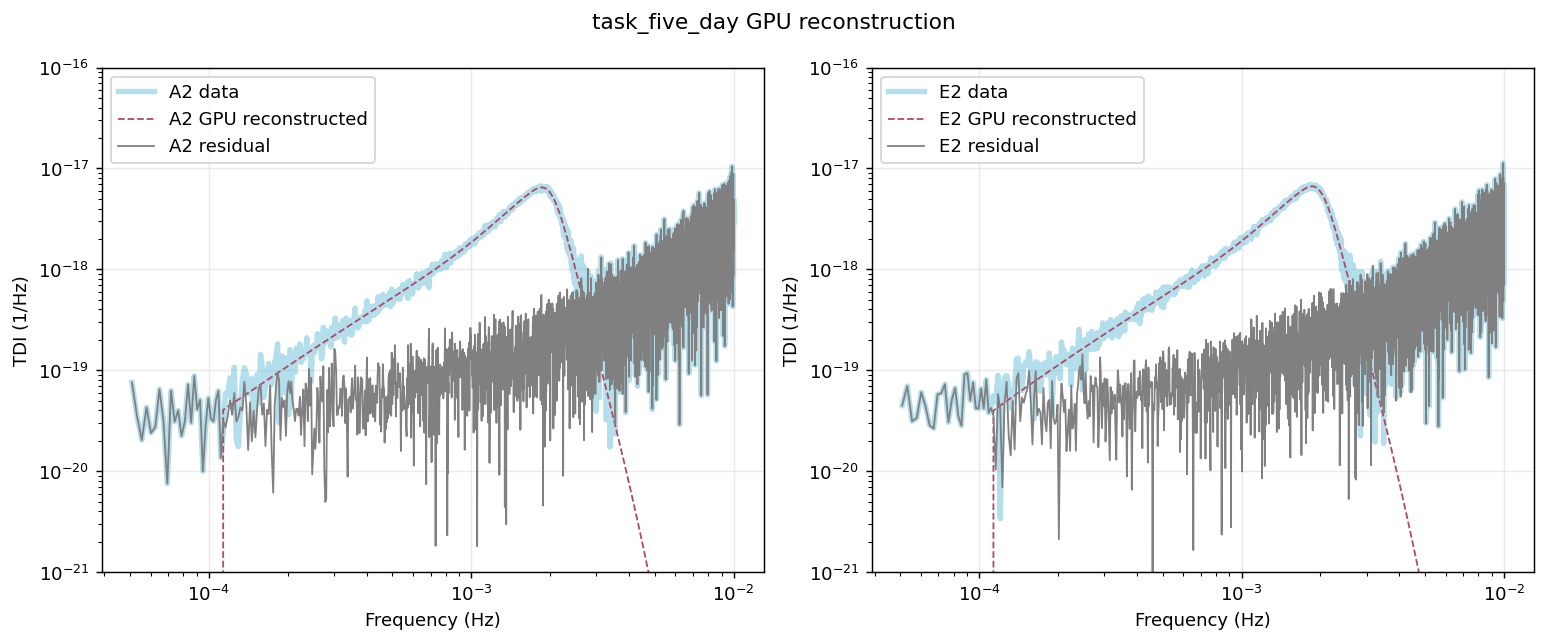

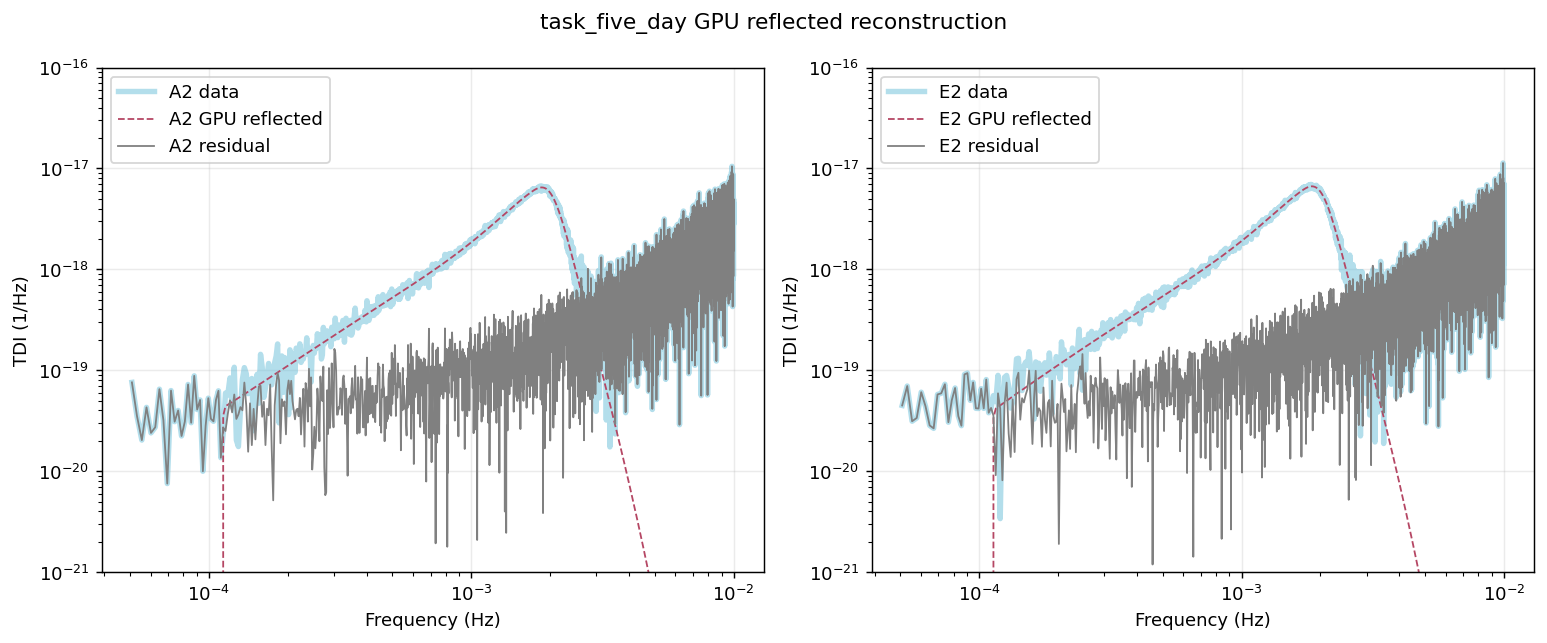

In [27]:
five_day_gpu_preflight = None
if RUN_GPU_PREFLIGHT and five_day_window is not None and FDTDI_GPU is not None:
    five_day_gpu_preflight = run_gpu_preflight(five_day_window, "task_five_day")
else:
    print("5-day GPU preflight skipped.")

five_day_gpu_search = None
five_day_gpu_FIM = None
if USE_CACHED_SEARCH_RESULTS and five_day_window is not None:
    five_day_gpu_search, five_day_gpu_FIM = load_gpu_search_from_cache(five_day_window, "task_five_day")
    if five_day_gpu_search is not None:
        plot_gpu_reconstruction(five_day_window, five_day_gpu_search, "07_five_day_reconstruction_direct.png")
        plot_gpu_reflected_reconstruction(five_day_window, five_day_gpu_search, "08_five_day_reconstruction_reflected.png")
elif RUN_GPU_FSTAT_SEARCH and five_day_window is not None:
    five_day_gpu_search = run_gpu_fstat_search(five_day_window, "task_five_day")
    plot_gpu_reconstruction(five_day_window, five_day_gpu_search, "07_five_day_reconstruction_direct.png")
    plot_gpu_reflected_reconstruction(five_day_window, five_day_gpu_search, "08_five_day_reconstruction_reflected.png")
else:
    print("5-day GPU F-statistics search code is present but not executed.")

if "five_day_gpu_FIM" not in globals():
    five_day_gpu_FIM = None
if RUN_GPU_FISHER and five_day_gpu_search is not None and five_day_gpu_FIM is None:
    five_day_gpu_FIM = run_gpu_fisher_analysis(five_day_window, five_day_gpu_search)
if five_day_gpu_search is not None and five_day_gpu_FIM is not None:
    five_day_gpu_search_comparison = compare_search_to_injection(five_day_window, five_day_gpu_search, five_day_gpu_FIM)
    five_day_gpu_search_comparison.to_csv(RESULT_DIR / "task_five_day_gpu_search_vs_injection.csv", index=False)
    display(five_day_gpu_search_comparison)
else:
    print("5-day GPU Fisher code is present but not executed.")

five_day_gpu_nessai_sampler = None
five_day_gpu_summary = None
if RUN_GPU_NESSAI_SAMPLER and five_day_gpu_search is not None and five_day_gpu_FIM is not None:
    five_day_gpu_nessai_sampler, five_day_gpu_summary = run_gpu_nessai_sampler(five_day_gpu_search, five_day_gpu_FIM, "task_five_day")
    display(five_day_gpu_summary)
else:
    print("5-day GPU heterodyned NESSAI code is present but not executed.")

five_day_gpu_ensemble = None
five_day_gpu_eryn_summary = None
if RUN_GPU_ERYN_SAMPLER and five_day_gpu_search is not None:
    five_day_gpu_ensemble, five_day_gpu_out = run_gpu_eryn_sampler(five_day_gpu_search, label="task_five_day")
    five_day_gpu_eryn_summary = summarize_gpu_eryn_chain(five_day_gpu_ensemble, label="task_five_day")
    if five_day_gpu_summary is None:
        five_day_gpu_summary = five_day_gpu_eryn_summary
    display(five_day_gpu_eryn_summary)
else:
    print("5-day GPU Eryn sampler code is present but not executed.")


## 20. GPU Baseline vs Modified-Window Comparison


In [28]:
gpu_comparison = pd.DataFrame(columns=["parameter", "baseline_median", "baseline_ci90_low", "baseline_ci90_high", "baseline_ci90_width", "five_day_median", "five_day_ci90_low", "five_day_ci90_high", "five_day_ci90_width", "ci90_width_ratio_5day_over_baseline"])
if baseline_gpu_summary is not None and five_day_gpu_summary is not None:
    gpu_comparison = compare_summaries(baseline_gpu_summary, five_day_gpu_summary)
    gpu_comparison.to_csv(RESULT_DIR / "baseline_vs_five_day_gpu_nessai_parameter_summary.csv", index=False)
display(gpu_comparison)


,parameter,baseline_median,baseline_ci90_low,baseline_ci90_high,baseline_ci90_width,five_day_median,five_day_ci90_low,five_day_ci90_high,five_day_ci90_width,ci90_width_ratio_5day_over_baseline
0,chirp_mass,2.996122e+06,2.992059e+06,3.000232e+06,8172.592015,2.997570e+06,2.993981e+06,3.001150e+06,7169.526864,0.877265
1,coalescence_phase,1.824524e+00,1.809447e+00,1.838520e+00,0.029073,1.824407e+00,1.809761e+00,1.838569e+00,0.028808,0.990866
2,coalescence_time,2.501108e+01,2.501105e+01,2.501111e+01,0.000054,2.501108e+01,2.501105e+01,2.501110e+01,0.000054,0.995159
3,inclination,1.885180e+00,1.877171e+00,1.889473e+00,0.012302,1.885040e+00,1.876506e+00,1.889347e+00,0.012841,1.043783
4,latitude,-7.289212e-01,-1.066484e+00,-3.839887e-01,0.682495,-7.396897e-01,-1.082043e+00,-4.062275e-01,0.675815,0.990212
5,longitude,2.181357e+00,1.780326e+00,2.539837e+00,0.759511,2.205240e+00,1.804484e+00,2.570422e+00,0.765939,1.008462
6,luminosity_distance,4.475254e+04,3.868872e+04,4.863876e+04,9950.041274,4.439454e+04,3.832999e+04,4.857113e+04,10241.136750,1.029256
7,mass_ratio,2.502197e-01,2.480861e-01,2.524686e-01,0.004382,2.506683e-01,2.485928e-01,2.527285e-01,0.004136,0.943694
8,psi,1.870572e+00,1.618272e+00,2.101273e+00,0.483001,1.852489e+00,1.590550e+00,2.088356e+00,0.497806,1.030653
9,spin_1z,3.951501e-01,3.813940e-01,4.083316e-01,0.026938,3.938682e-01,3.804364e-01,4.069244e-01,0.026488,0.983310


## 21. Official-Style GPU NESSAI Posterior Distribution and Taiji-Frame Position

These figures reproduce the two visual checks emphasized in the official Example 4 notebook, now using the full GPU-heterodyned NESSAI posterior samples rather than the earlier CPU smoke-test posterior. The corner plots are regenerated from the tracked full NESSAI posterior CSV files. Orange solid reference lines mark the direct injected parameters; red dashed reference lines mark the ecliptic-reflected injection generated with `Triangle_BBH.Utils.get_reflected_parameter_dict`, which is the branch on which the GPU F-statistics search and local heterodyned NESSAI posterior are centered.

### Baseline Example 4 Window

![Baseline GPU NESSAI posterior corner](../figures/task5_subtask2/17_baseline_gpu_nessai_corner.png)

![Baseline GPU NESSAI Taiji-frame position](../figures/task5_subtask2/09_baseline_taiji_frame_sky.png)

### Task 5-Day Window

![5-day GPU NESSAI posterior corner](../figures/task5_subtask2/18_five_day_gpu_nessai_corner.png)

![5-day GPU NESSAI Taiji-frame position](../figures/task5_subtask2/10_five_day_taiji_frame_sky.png)


## 22. Full GPU-Heterodyned NESSAI Diagnostics

The full GPU-heterodyned NESSAI runs completed with 
live=2000, stopping=0.1, seed=1234, and CUDA-enabled PyTorch. The compact JSON/CSV outputs are tracked under 
esults/task5_subtask2/; the native heavy sampler directories remain local outputs.

### Baseline Example 4 Window

![Baseline insertion-index diagnostic](../figures/task5_subtask2/11_baseline_nessai_insertion_indices.png)

![Baseline NESSAI trace](../figures/task5_subtask2/12_baseline_nessai_trace.png)

![Baseline logX-logL evidence track](../figures/task5_subtask2/13_baseline_nessai_logXlogL.png)

### Task 5-Day Window

![5-day insertion-index diagnostic](../figures/task5_subtask2/14_five_day_nessai_insertion_indices.png)

![5-day NESSAI trace](../figures/task5_subtask2/15_five_day_nessai_trace.png)

![5-day logX-logL evidence track](../figures/task5_subtask2/16_five_day_nessai_logXlogL.png)


## 23. Final Discussion Notes

The full production route follows the task requirement to use NESSAI nested sampling while replacing the slow full-frequency CPU likelihood with the GPU BBHx heterodyned likelihood. Both windows use the real TDC files, the official XYZ-to-A/E preprocessing, the same frequency band, and the same local-fisher prior construction around the GPU F-statistics search result.

The baseline Example 4 window (`tc - 2.5 days` to `tc + 2.5 days`) completed with `nlive=2000`, `logZ = 594014.861 +/- 0.124`, 10,890 posterior samples, and a measured sampler wall time of 9.44 minutes. The required 5-day window (`tc - 4 days` to `tc + 1 day`) completed with `logZ = 594995.406 +/- 0.125`, 10,879 posterior samples, and a measured wall time of 9.59 minutes. CUDA-enabled PyTorch was active for both runs. The two `logZ` values are reported as per-run NESSAI evidence/convergence diagnostics only; their difference must not be interpreted as a Bayes factor or as Bayesian evidence favoring the 5-day data window because the two runs use different data segments.

The auxiliary insertion-index KS p-values are 0.480 for the baseline and 0.357 for the 5-day window, and the maximum posterior boundary fractions are 0.0065 and 0.0074 respectively. These checks do not replace NESSAI's native diagnostics, but they support the conclusion that neither local posterior is obviously truncated by the Fisher box or failing the lightweight insertion-rank screen.

The 5-day window narrows the chirp-mass CI90 width by about 12.3%, leaves the coalescence-time and sky-position widths nearly unchanged, and slightly widens the luminosity-distance CI90 width by about 2.9%. These are local reflected-branch posterior comparisons, not a global sky-mode comparison. The F-statistics search is centered on the ecliptic-reflected branch; the corner plots therefore show orange solid lines for the direct injected parameters and red dashed lines for the reflected injection reference generated with `get_reflected_parameter_dict`. The report should discuss this direct/reflected degeneracy explicitly.

Main limitations: the heterodyned likelihood is local to its fiducial waveform, the local-fisher prior intentionally does not explore both sky-reflection modes in one run, and PSD estimates differ because the two windows use different pre-event noise segments. A rigorous direct-versus-reflected evidence comparison should run two separate local-fisher branches with their own fiducials rather than a single wide-sky heterodyned run.
